In [2]:
# PP = pd.read_csv(TAB / "wp4_prior_predictive_stats_n200.csv")
# z = np.load(TAB / "wp4_prior_predictive_profiles_n200.npz"); PROF_G, PROF_M = z["PROF_G"], z["PROF_M"]
# print("resumed Step 11 from its files")



**This copy runs from the `SVOI_OD` folder** (open it with this folder as the working directory). Inputs are read from `01_citation_table/`, `03_sampler_inputs/` and `04_prior_predictive_observed/`; figures and tables are written to `08_prior_models/`. It is generated from `02_code/notebooks/wp4_period_prior_sediment_hosted.ipynb` by the folder builder; edit that one.


In [4]:
# --- journal figure style ---------------------------------------------------
# Every text element has an explicit size; figures are drawn at final printed
# width so the point sizes below are the sizes that reach the page.
import matplotlib.pyplot as plt

FS_TICK, FS_LABEL, FS_LEGEND, FS_ANNOT, FS_PANEL = 8, 9, 8, 7, 9
COL1, COL15, COL2 = 3.5, 5.5, 7.2      # single / 1.5 / double column width (in)

plt.rcParams.update({
    # typeface
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "font.size": FS_TICK,
    # text elements
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_PANEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.title_fontsize": FS_LEGEND,
    "figure.titlesize": FS_LABEL,
    # axes furniture: thin frame, ticks inward on all four sides, minor ticks
    "axes.linewidth": 0.6,
    "axes.grid": False,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4, "ytick.minor.width": 0.4,
    "xtick.major.size": 3.0, "ytick.major.size": 3.0,
    "xtick.minor.size": 1.8, "ytick.minor.size": 1.8,
    # marks
    "lines.linewidth": 1.0,
    "lines.markersize": 3.0,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.borderaxespad": 0.4,
    # output
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

def panel_labels(axes, labels=("(a)", "(b)")):
    """Bold (a)/(b) above the top-left corner of each axes."""
    for ax, lab in zip(axes, labels):
        ax.set_title(lab, loc="left", fontsize=FS_PANEL, fontweight="bold")

# --- batlow: Crameri's scientific colour map (Crameri et al. 2020, Nat. Commun.)
# 32 anchor points interpolated to 256 steps; reproduces the published map to
# within 1.4/255 per channel. Embedded so the notebook needs no extra package.
from matplotlib.colors import LinearSegmentedColormap
_BATLOW = [
    (0.0052, 0.0982, 0.3498), (0.0321, 0.1468, 0.3582), (0.0494, 0.1911, 0.3658), (0.0592, 0.2298, 0.3723),
    (0.0679, 0.2671, 0.3782), (0.0771, 0.2970, 0.3824), (0.0903, 0.3257, 0.3849), (0.1097, 0.3531, 0.3842),
    (0.1413, 0.3812, 0.3771), (0.1778, 0.4030, 0.3638), (0.2201, 0.4219, 0.3443), (0.2662, 0.4386, 0.3201),
    (0.3208, 0.4560, 0.2898), (0.3709, 0.4711, 0.2621), (0.4225, 0.4861, 0.2345), (0.4762, 0.5013, 0.2081),
    (0.5402, 0.5186, 0.1831), (0.6005, 0.5336, 0.1706), (0.6627, 0.5475, 0.1740), (0.7243, 0.5596, 0.1954),
    (0.7906, 0.5714, 0.2362), (0.8457, 0.5817, 0.2826), (0.8958, 0.5938, 0.3379), (0.9378, 0.6096, 0.4023),
    (0.9708, 0.6324, 0.4833), (0.9864, 0.6555, 0.5571), (0.9923, 0.6790, 0.6283), (0.9930, 0.7020, 0.6958),
    (0.9914, 0.7276, 0.7703), (0.9891, 0.7510, 0.8380), (0.9860, 0.7753, 0.9084), (0.9814, 0.8004, 0.9813),
]
BATLOW = LinearSegmentedColormap.from_list("batlow", _BATLOW, N=256)

import matplotlib.patheffects as _pe
HALO = [_pe.withStroke(linewidth=1.6, foreground="white")]   # keeps markers and
# labels legible where they sit on a filled colour field


## Data

Read from `SVOI_OD/`: the citation table (`01_citation_table/`), O'Driscoll's 1974 targets and the regional window (`03_sampler_inputs/`). `04_prior_predictive_observed/` is not opened until Step 8.


In [5]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from scipy import ndimage, stats
from pyproj import Transformer
import discretize

PM = Path(".")                                               # this notebook sits in the SVOI_OD folder
FIG = Path("08_prior_models/figures")
TAB = Path("08_prior_models")
assert (PM / "01_citation_table").is_dir(), "run from the SVOI_OD folder"
FIG.mkdir(parents=True, exist_ok=True)

CT = pd.read_csv(PM / "01_citation_table/wp4_annexA_citation_table_draft.csv").set_index("row_id")
TG = pd.read_csv(PM / "03_sampler_inputs/wp4_prior_lineament_targets_1974.csv")
WIN = pd.read_csv(PM / "03_sampler_inputs/study_windows.csv").set_index("window").loc["regional"]
ANNEX_GREY = "#e3e3e3"                                  # shading for a confirmed or stated range
OD_LON, OD_LAT = 136.887, -30.441                      # Olympic Dam, for orientation only; never used by the sampler

def cited(row, *numbers):
    """assert that every number the code uses for a row is written in that row's confirmed distribution"""
    txt = CT.loc[row, "proposed_distribution"].replace(",", "")
    written = {float(x) for x in re.findall(r"\d+\.?\d*", txt)}
    for v in numbers:
        assert float(v) in written, (row, v, txt)
    assert str(CT.loc[row, "confirmed"]).startswith("confirmed") or "confirmed" in str(CT.loc[row, "confirmed"]), row
    return True

print(f"citation table: {len(CT)} rows, all confirmed: {bool(CT.confirmed.str.contains('confirmed').all())}")
print(CT[["parameter", "status"]].to_string())
print(f"\nO'Driscoll 1974 targets: {len(TG)}, in the regional window: {int(TG.in_regional_window.sum())}")


citation table: 17 rows, all confirmed: True
                                                                    parameter                                          status
row_id                                                                                                                       
L1-1                                        Cover unit thicknesses (per unit)                     cited; unit shares declared
L1-2                                Between-bore thickness variance and trend                             declared assumption
L1-3                                             Basement unconformity relief                                      translated
L2-1                           Basalt object intensity (count per 10,000 km2)                             declared assumption
L2-2                                         Basalt lateral extent; thickness                                           cited
L2-3                                           Lineament intensity multip

## The sampler

`realize(seed)` draws the 22 quantities of the citation table from one random stream and evaluates the five levels in order on the map grid $\mathbf{x} \in \Omega$ (113 x 120 km, 1 km cells). Depth $z$ is positive downward. Throughout, $g(\mathbf{x};\ell)$ denotes a zero-mean, unit-variance Gaussian random field with covariance $C(h) = \exp(-h^2/\ell^2)$, generated spectrally; an anisotropic field $g(\mathbf{x};\ell_\parallel,\ell_\perp,\theta)$ takes two lengths and a strike. $U$, $\mathrm{LogU}$, $N$ and $\mathrm{TN}$ are the uniform, log-uniform, normal and truncated normal distributions. Each draw is labelled by its row; the source behind the row is given in the table at the end of this cell.

**Level 1, stratigraphic frame.** The total cover to basement is one draw, $T \sim U(320, 670)$ m (L1-1). Its variation over the window is a random field plus a planar trend of random strike,

$$c(\mathbf{x}) = T\left[1 + 0.2\,g(\mathbf{x};\ell) + 0.2\,t(\mathbf{x})\right], \qquad \ell \sim \mathrm{LogU}(10, 50)\ \text{km} \quad \text{(L1-2)},$$

and the unconformity carries its own relief, $z_b(\mathbf{x}) = c(\mathbf{x}) + A\,\tilde g(\mathbf{x};\ell)$, with $\tilde g$ rescaled to $[-\tfrac12, \tfrac12]$ and $A \sim U(0, 150)$ m (L1-3). Unit tops are fixed shares of $c$: the Stuart Shelf succession occupies the upper 0.46 (Andamooka Limestone 0.075 of it, then Arcoona Quartzite 0.24, siltstones 0.23 and Woomera Shale 0.53 of the remainder) and the Pandurra Formation the lower 0.54; $s_4(\mathbf{x}) = 0.46\,c(\mathbf{x})$ is the top of the Pandurra.

**Level 2, basalt piles and iron-oxide bodies.** Piles form a marked point process on the unconformity. Their number is $N \sim \mathrm{Poisson}(\lambda A_\Omega / 10^4)$ with $\lambda \sim U(2, 10)$ per $10^4$ km$^2$ (L2-1) and $A_\Omega$ = 13,560 km$^2$. Centres are placed with density

$$w(\mathbf{x}) \propto \frac{M^{\,\mathbb{1}[\mathbf{x} \in \mathcal{C}]}}{f_{\mathcal{C}}\,M + 1 - f_{\mathcal{C}}}, \qquad M \sim U(1, 18) \quad \text{(L2-3)},$$

where $\mathcal{C}$ is the union of O'Driscoll's 1974 target circles and $f_{\mathcal{C}}$ = 0.066 its share of the window, so the expected count is independent of $M$. Each pile is an ellipse of long axis $L \sim \mathrm{LogU}(2, 20)$ km, aspect 1.3 and strike 157 deg, with thickness $\tau \sim \mathrm{LogU}(75, 300)$ m (L2-2); it occupies $\max(z_b - \tau,\ s_4) \le z < z_b$, that is, it rests on the basement inside the Pandurra. Iron-oxide bodies (L2-4) are a second population, $N_{Fe} \sim \mathrm{Poisson}(0.375\,\lambda A_\Omega/10^4)$, placed uniformly, with long axis $\mathrm{LogU}(0.3, 3)$ km, aspect 3, north-south strike, vertical extent 200 m below $z_b$, and density $\rho_{Fe} \sim U(3.0, 4.5)$ g/cm$^3$ per body. A body smaller than a cell keeps its mass through the fill fraction $\phi$ of the cell it occupies: $\rho_{cell} = \rho_b + \phi\,(\rho_{Fe} - \rho_b)$, and likewise for susceptibility.

**Level 3, redox architecture.** Reduced facies at the contact is the exceedance set of an anisotropic field,

$$R(\mathbf{x}) = \mathbb{1}\!\left[\,g(\mathbf{x};\ \ell_b/3,\ \ell_b/9.6,\ 10^\circ) \ge q_{1-p}\,\right], \qquad p \sim U(0.05, 0.30) \ \text{(L3-1)}, \quad \ell_b \sim \mathrm{LogU}(30, 150)\ \text{km} \ \text{(L3-2)},$$

with $q_{1-p}$ the $(1-p)$ quantile of the field, so the reduced fraction of the window equals $p$ exactly; $\ell_b$ is the belt length and the aspect 3.2 and strike 10 deg follow the Mount Gunson corridor.

**Level 4, ore rule.** Ore is permitted only in the margin zone

$$Z = \left\{\mathbf{x} : \mathrm{dist}(\mathbf{x}, \text{basalt}) \le \max(d,\ 0.5\ \text{km})\right\} \cap \{R = 1\}, \qquad d \sim U(0, 15)\ \text{km} \quad \text{(L4-1)}.$$

Blankets are disks of diameter $D \sim \mathrm{LogU}(0.5, 5)$ km (L3-2, the patch scale); their number is $N_{ore} \sim \mathrm{Poisson}(P\,|Z|/\bar a)$ with $P \sim U(0.09, 0.35)$ the fraction of the zone they cover (L4-2) and $\bar a$ the mean disk area, and their centres are weighted by $M_4 \sim U(1, 5)$ inside $\mathcal{C}$ (L4-3), the lineament-intersection factor. Each disk has thickness $h \sim \mathrm{LogU}(1, 15)$ m and grade $G \sim U(1, 4.5)$% Cu (L4-4); its tonnage $\pi D^2 h \rho_{host}/4$ is derived, not drawn. The grade enters the property volumes as the chalcopyrite volume fraction,

$$\Delta\rho = v\,(\rho_{ccp} - \rho_{host}), \qquad v = \frac{G/100}{0.346}\,\frac{\rho_{host}}{\rho_{ccp}}, \qquad \rho_{ccp} = 4.2\ \text{g/cm}^3 \quad \text{(L5-3)},$$

a few hundredths of a g/cm$^3$ over 1 to 15 m: the blanket is invisible to gravity and magnetics, as the concept requires.

**Level 5, petrophysical attachment.** Each pile draws a density $\rho \sim \mathrm{TN}(2.80, 0.12;\ 2.60, 3.35)$ g/cm$^3$ and a susceptibility $k \sim \mathrm{LogU}(20, 26{,}000) \times 10^{-6}$ cgs (L5-1). The cover units draw one value each per realization (L5-2): quartzite $U(2.60, 2.70)$, shale and siltstone $U(2.10, 2.60)$, limestone $U(2.20, 2.70)$, Pandurra $N(2.44, 0.05)$; $k_{cover} \sim \mathrm{LogU}(10, 100)$; resistivity $\mathrm{LogU}(1, 1000)$ ohm-m. The basement carries two lateral fields with a common two-scale geometry (L5-4),

$$Z(\mathbf{x}) = \sqrt{0.8}\,g(\mathbf{x}; 30\ \text{km}) + \sqrt{0.2}\,g(\mathbf{x}; 4\ \text{km}),$$
$$\rho_b(\mathbf{x}) = \left[2.65 + \sigma_\rho Z(\mathbf{x})\right]_{2.50}^{3.12}, \quad \sigma_\rho \sim U(0.03, 0.10); \qquad
\log_{10} k_b(\mathbf{x}) = \left[\log_{10} 1{,}120 + \sigma_k Z'(\mathbf{x})\right]_{1}^{4.3}, \quad \sigma_k \sim U(0.5, 1.0),$$

with $Z'$ an independent copy of $Z$ and $[\cdot]_a^b$ clipping to $[a, b]$; both fields are constant with depth. Basalt and basement resistivities are fixed at 3,100 and 5,000 ohm-m. No shear velocity is attached, because no era value existed.

**Sources behind the rows.** Every distribution above is the translation of a pre-t0 document recorded in the citation table; the table below names the source of each row.

| Row | Draw | Source (pre-1975) |
|---|---|---|
| L1-1 | $T$ | Bulletin 41 (Johns 1968) Tent Hill minimum; Johns 1974 Pandurra minimum; LY 2 log (CSR 1974), end of hole in Pandurra at 667 m |
| L1-2, L1-3 | $\ell$, $A$ | t0 bore spacing; Woomera Shale thinning over the Pernatty Grit high (Bulletin 41 p. 29) |
| L2-1, L2-2 | $\lambda$; $L$, $\tau$ | declared; Roopena outcrop (PORT AUGUSTA 1968) and holes (Risely 1968) |
| L2-3, L4-3 | $M$, $M_4$ | O'Driscoll's 1974 target sheet (20 targets, 5.4% of the sheet, $1/f = 18$) |
| L2-4 | $N_{Fe}$, $L_{Fe}$, $\rho_{Fe}$ | Iron Knob and Iron Monarch dimensions (RB 33/00090, Bull 009); Task 3 class weights |
| L3-1, L3-2 | $p$; $\ell_b$, $D$ | t0 bore facies; Copperbelt and Kupferschiefer belt and patch scales; Mount Gunson corridor (Johns 1972) |
| L4-1, L4-2 | $d$, $P$ | Maiden's 1 to 15 km from the basin edge; ore fractions of belt length (Haynes's memoranda not in open file) |
| L4-4 | $h$, $G$ | PP 820 copper chapter and the analog deposit papers |
| L5-1, L5-2 | $\rho$, $k$; unit values | Risely 1968 specific gravities; Dobrin 1960, Grant and West 1965, Parasnis 1973 (Table I in rationalised units) |
| L5-3 | $\Delta\rho$ | derived (Parasnis Table V chalcopyrite) |
| L5-4 | $\sigma_\rho$, $\sigma_k$ | Dobrin Tables 12-1 and 13-1, Parasnis, Risely; Grant and West Tables 12-2 and 12-3 |

Fixed settings without a row (listed in the README): the unit shares, the object shapes, the chalcopyrite constants, the iron-body count ratio and susceptibility (5,000 x 1e-6 cgs), the basement means and limits, and the two-scale geometry. Sampler choices: trend amplitude equal to the 20% residual sd, $c$ floored at 50 m, reach at least half a cell.


In [6]:
# ---- mesh: regional window in GDA94 / MGA zone 53, 1 km cells, 25 m layers to 2 km then padding -----------------
to_mga = Transformer.from_crs("EPSG:4326", "EPSG:28353", always_xy=True)
xs, ys = to_mga.transform([WIN.lon_min, WIN.lon_max, WIN.lon_min, WIN.lon_max], [WIN.lat_min, WIN.lat_min, WIN.lat_max, WIN.lat_max])
X0, X1, Y0, Y1 = np.floor(min(xs) / 1e3) * 1e3, np.ceil(max(xs) / 1e3) * 1e3, np.floor(min(ys) / 1e3) * 1e3, np.ceil(max(ys) / 1e3) * 1e3
DX = 1000.0
NX, NY = int((X1 - X0) / DX), int((Y1 - Y0) / DX)
HZ = [25.0] * 80 + [25.0 * 1.5 ** k for k in range(1, 11)]          # 80 x 25 m to 2 km, then 10 padding layers to about 6.3 km
MESH = discretize.TensorMesh([[DX] * NX, [DX] * NY, HZ[::-1]], origin=[X0, Y0, -sum(HZ)])
ZC = -MESH.cell_centers_z[::-1]                        # cell-centre depths below surface (m), top layer first
XC = X0 + DX * (np.arange(NX) + 0.5); YC = Y0 + DX * (np.arange(NY) + 0.5)
GX, GY = np.meshgrid(XC, YC)                           # (NY, NX) map grid
AREA_KM2 = NX * NY * (DX / 1e3) ** 2
TX, TYY = to_mga.transform(TG.lon.values, TG.lat.values)
IN_CIRCLE = np.zeros((NY, NX), bool)
for x, y, r in zip(TX, TYY, TG.radius_km.values):
    IN_CIRCLE |= (GX - x) ** 2 + (GY - y) ** 2 <= (r * 1e3) ** 2
ODX, ODY = to_mga.transform(OD_LON, OD_LAT)

# ---- fixed settings (held constant, not sampled; README of annexA_prior_model) --------------------------------------
FIX = dict(rho_basement=2.60, k_basement=500.0, res_basalt=3100.0, res_basement=5000.0,
           basalt_aspect=4.7 / 3.6, basalt_az=157.0,          # Roopena outcrop, PORT AUGUSTA 1968
           belt_aspect=32.0 / 10.0, belt_az=10.0,              # Mount Gunson corridor, Johns 1972 (RB 72/00189)
           cu_in_ccp=0.346, rho_ccp=4.2,                       # chalcopyrite, Parasnis 1973 Table V
           iron_ratio=0.15 / 0.40, iron_aspect=3.0, iron_az=0.0, iron_thick_m=200.0, k_iron=5000.0,   # Change 1: iron-oxide bodies (Task 3 weights; Middleback reports)
           rho_b_mean=2.65, rho_b_min=2.50, rho_b_max=3.12,                                          # Change 1: basement density field
           k_b_median=1120.0, k_b_min=10.0, k_b_max=20000.0,                                          # Change 2: basement susceptibility field (L5-6); Change 4: median 1,120 (Grant and West Table 12-3, rhyolite)
           domain_km=30.0, texture_km=4.0, domain_share=0.8)                                          # Change 5: two-scale basement fields (both), share of variance at the domain scale; replaces the 20 km and 16 km single scales
LITH = {1: "Andamooka Limestone", 2: "Arcoona Quartzite", 3: "unnamed siltstones", 4: "Woomera Shale",
        5: "Pandurra Formation", 6: "basalt", 7: "basement", 8: "iron-oxide body"}

# ---- the draws, each tied to its citation row -------------------------------------------------------------------------
cited("L1-1", 320, 670, 0.46, 0.54, 0.075, 0.24, 0.23, 0.53)                               # Change 6 (2026-09-23): one draw, total cover to basement
cited("L1-2", 20, 10, 50); cited("L1-3", 0, 150); cited("L2-1", 2, 10); cited("L2-2", 2, 20, 75, 300)
cited("L2-3", 1, 18); cited("L3-1", 0.05, 0.30); cited("L3-2", 30, 150, 0.5, 5); cited("L4-1", 0, 15)
cited("L4-2", 0.09, 0.35); cited("L4-3", 1, 5); cited("L4-4", 1, 15, 1.0, 4.5)
cited("L5-1", 2.80, 0.12, 2.60, 3.35, 20, 26000); cited("L5-2", 2.60, 2.70, 2.10, 2.20, 2.44, 0.05, 10, 100, 1, 1000)
cited("L2-4", 0.3, 3, 3.0, 4.5); cited("L5-4", 0.03, 0.10, 0.5, 1.0)                        # Change 1 and 2 rows (2026-09-23), bundled in Change 6: iron-body size; density, basement density; susceptibility variation
U = lambda r, a, b: r.uniform(a, b)
LU = lambda r, a, b: float(np.exp(r.uniform(np.log(a), np.log(b))))

def draw(r):
    """one set of realization-level parameters; row ids in the keys"""
    return {"L1-1 cover_total_m": U(r, 320, 670),                       # Change 6: total cover to basement, one draw; units are fixed fractions of it
            "L1-2 corr_length_km": LU(r, 10, 50), "L1-3 relief_m": U(r, 0, 150),
            "L2-1 intensity_per_1e4km2": U(r, 2, 10), "L2-3 basalt_multiplier": U(r, 1, 18),
            "L3-1 p_reduced": U(r, 0.05, 0.30), "L3-2 belt_length_km": LU(r, 30, 150),
            "L4-1 reach_d_km": U(r, 0, 15), "L4-2 p_ore": U(r, 0.09, 0.35), "L4-3 ore_multiplier": U(r, 1, 5),
            "L5-2 rho_quartzite": U(r, 2.60, 2.70), "L5-2 rho_shale": U(r, 2.10, 2.60), "L5-2 rho_limestone": U(r, 2.20, 2.70),
            "L5-2 rho_pandurra": r.normal(2.44, 0.05), "L5-2 k_cover": LU(r, 10, 100), "L5-2 res_cover": LU(r, 1, 1000)}

def grf(r, lx_km, ly_km=None, az=0.0, pad=2):
    """zero-mean unit-variance Gaussian random field on the map grid; correlation lengths along az and across it"""
    ly_km = lx_km if ly_km is None else ly_km
    ny, nx = NY * pad, NX * pad
    kx = np.fft.fftfreq(nx, d=DX / 1e3) * 2 * np.pi; ky = np.fft.fftfreq(ny, d=DX / 1e3) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky); a = np.radians(az)
    kpar = KX * np.sin(a) + KY * np.cos(a); kper = KX * np.cos(a) - KY * np.sin(a)
    amp = np.exp(-((kpar * lx_km) ** 2 + (kper * ly_km) ** 2) / 8.0)
    f = np.real(np.fft.ifft2(np.fft.fft2(r.standard_normal((ny, nx))) * amp))[:NY, :NX]
    return (f - f.mean()) / f.std()

def ellipse(x0, y0, length_km, aspect, az):
    a = np.radians(az); dx, dy = (GX - x0) / 1e3, (GY - y0) / 1e3
    u = dx * np.sin(a) + dy * np.cos(a); v = dx * np.cos(a) - dy * np.sin(a)
    return (u / (length_km / 2)) ** 2 + (v / (length_km / 2 / aspect)) ** 2 <= 1.0

def weighted_points(r, n, weight, mask=None):
    """n random map points with probability proportional to weight (optionally inside mask); jittered inside cells"""
    w = weight.astype(float) * (1 if mask is None else mask)
    if n == 0 or w.sum() == 0: return np.empty(0), np.empty(0)
    idx = r.choice(w.size, size=n, p=(w / w.sum()).ravel())
    iy, ix = np.unravel_index(idx, w.shape)
    return XC[ix] + r.uniform(-DX / 2, DX / 2, n), YC[iy] + r.uniform(-DX / 2, DX / 2, n)

# ---- the five levels as stages; a branch is data that names its draw, stages, properties and summary (Section 7) ----------
def level1_frame(r, p, F):
    T0, lc = p["L1-1 cover_total_m"], p["L1-2 corr_length_km"]
    g = np.radians(r.uniform(0, 360))
    trend = ((GX - GX.mean()) * np.sin(g) + (GY - GY.mean()) * np.cos(g)) / (NX * DX / 2)
    total = np.clip(T0 * (1 + 0.20 * grf(r, lc) + 0.20 * trend), 50, None)          # total cover to basement (L1-1), one draw
    cover = total * 0.46                                                            # Stuart Shelf succession 0.46, Pandurra 0.54 (fixed shares, row L1-1)
    fl = 0.075                                                                      # Andamooka Limestone share of the succession (fixed, row L1-1)
    s1 = cover * fl; s2 = s1 + cover * (1 - fl) * 0.24; s3 = s2 + cover * (1 - fl) * 0.23; s4 = cover
    rel = grf(r, lc); rel = p["L1-3 relief_m"] * ((rel - rel.min()) / (rel.max() - rel.min()) - 0.5)
    return dict(cover=cover, s1=s1, s2=s2, s3=s3, s4=s4, base=total + rel)         # base = top of basement

def level2_basalt(r, p, F):
    lam, M2, fin = p["L2-1 intensity_per_1e4km2"], p["L2-3 basalt_multiplier"], IN_CIRCLE.mean()
    n_obj = r.poisson(lam * AREA_KM2 / 1e4)
    bx, by = weighted_points(r, n_obj, np.where(IN_CIRCLE, M2, 1.0) / (fin * M2 + (1 - fin)))
    btop = np.full((NY, NX), np.nan); bid = np.zeros((NY, NX), int); objs = []
    for j, (x, y) in enumerate(zip(bx, by), 1):
        L = LU(r, 2, 20); t = LU(r, 75, 300)
        rho = stats.truncnorm.rvs((2.60 - 2.80) / 0.12, (3.35 - 2.80) / 0.12, loc=2.80, scale=0.12, random_state=r)
        k = LU(r, 20, 26000)                                              # L5-1, corrected 2026-09-23 (Parasnis Table I is in rationalised units)
        m = ellipse(x, y, L, FIX["basalt_aspect"], FIX["basalt_az"])
        btop = np.where(m, np.maximum(F["base"] - t, F["s4"]), btop); bid[m] = j
        objs.append(dict(obj=j, x=x, y=y, length_km=L, thickness_m=t, rho=rho, k=k,
                         in_circle=bool(IN_CIRCLE[np.argmin(abs(YC - y)), np.argmin(abs(XC - x))])))
    basalt = bid > 0
    return dict(btop=btop, bid=bid, basalt=basalt, objs=objs, contact=np.where(basalt, btop, F["base"]))

def level3_redox(r, p, F):
    Lb = p["L3-2 belt_length_km"]
    red = grf(r, Lb / 3.0, Lb / 3.0 / FIX["belt_aspect"], FIX["belt_az"])
    return dict(reduced=red >= np.quantile(red, 1 - p["L3-1 p_reduced"]))

def level4_ore(r, p, F):
    d, basalt = p["L4-1 reach_d_km"], F["basalt"]
    if basalt.any():
        dist = np.where(basalt, ndimage.distance_transform_edt(basalt), ndimage.distance_transform_edt(~basalt)) * DX / 1e3
        zone = (dist <= max(d, 0.5)) & F["reduced"]
    else:
        zone = np.zeros_like(F["reduced"])
    M4, P = p["L4-3 ore_multiplier"], p["L4-2 p_ore"]
    Dg = np.exp(np.linspace(np.log(0.5), np.log(5), 2001)); mean_area = np.mean(np.pi * Dg ** 2 / 4)
    n_ore = r.poisson(P * zone.sum() * (DX / 1e3) ** 2 / mean_area) if zone.any() else 0
    fz = (zone & IN_CIRCLE).sum() / max(zone.sum(), 1)
    ox, oy = weighted_points(r, n_ore, np.where(IN_CIRCLE, M4, 1.0) / (fz * M4 + (1 - fz)), zone)
    ores = []
    for x, y in zip(ox, oy):
        Dk = LU(r, 0.5, 5); th = LU(r, 1, 15); gr = U(r, 1.0, 4.5)
        host = p["L5-2 rho_pandurra"]
        vf = gr / 100 / FIX["cu_in_ccp"] * host / FIX["rho_ccp"]; drho = vf * (FIX["rho_ccp"] - host)
        ix, iy = np.argmin(abs(XC - x)), np.argmin(abs(YC - y))
        ores.append(dict(x=x, y=y, diam_km=Dk, thick_m=th, grade=gr, drho=drho, depth_m=F["contact"][iy, ix],
                         Mt=np.pi * Dk ** 2 / 4 * 1e6 * th * (host + drho) / 1e6, in_circle=bool(IN_CIRCLE[iy, ix])))
    return dict(zone=zone, ores=ores)

def level2_iron(r, p, F):
    """Change 1: iron-oxide bodies (Middleback type) in the basement, top at the unconformity; second object population"""
    n_iron = r.poisson(FIX["iron_ratio"] * p["L2-1 intensity_per_1e4km2"] * AREA_KM2 / 1e4)
    ix_, iy_ = weighted_points(r, n_iron, np.ones((NY, NX)))
    iid = np.zeros((NY, NX), int); irons = []
    for j, (x, y) in enumerate(zip(ix_, iy_), 1):
        L = LU(r, 0.3, 3); rho = U(r, 3.0, 4.5)
        m = ellipse(x, y, L, FIX["iron_aspect"], FIX["iron_az"])
        if not m.any():                                                    # smaller than a cell: keep the nearest cell
            m[np.argmin(abs(YC - y)), np.argmin(abs(XC - x))] = True
        area = np.pi * L ** 2 / 4 / FIX["iron_aspect"]
        fill = min(1.0, area / (m.sum() * (DX / 1e3) ** 2))               # fraction of the marked cells the body fills (mass kept)
        iid[m] = j
        irons.append(dict(obj=j, x=x, y=y, length_km=L, rho=rho, fill=fill, area_km2=area, depth_m=F["base"][np.argmin(abs(YC - y)), np.argmin(abs(XC - x))]))
    return dict(iid=iid, irons=irons)

def level5_basement(r, p, F):
    """Change 1: a lateral basement density field; Change 2: an independent log-normal susceptibility field (both row L5-4 since Change 6)"""
    W = FIX["domain_share"]
    two_scale = lambda: np.sqrt(W) * grf(r, FIX["domain_km"]) + np.sqrt(1 - W) * grf(r, FIX["texture_km"])   # Change 5: domains plus texture, unit variance
    sd = U(r, 0.03, 0.10)                                                 # row L5-4, drawn here so that the earlier stages keep their seeds
    rb = np.clip(FIX["rho_b_mean"] + sd * two_scale(), FIX["rho_b_min"], FIX["rho_b_max"])
    sdk = U(r, 0.5, 1.0)                                                  # row L5-4, decades
    logk = np.clip(np.log10(FIX["k_b_median"]) + sdk * two_scale(), np.log10(FIX["k_b_min"]), np.log10(FIX["k_b_max"]))
    return dict(rho_base=rb, k_base=10.0 ** logk, basement_sd=sd, basement_logk_sd=sdk)

def level5_properties(p, F):
    z = ZC[None, None, :]
    lith = np.full((NY, NX, len(ZC)), 7, np.int8)
    for code, surf in [(1, F["s1"]), (2, F["s2"]), (3, F["s3"]), (4, F["s4"]), (5, F["base"])]:
        lith[(lith == 7) & (z < surf[:, :, None])] = code
    lith[(z >= F["btop"][:, :, None]) & (z < F["base"][:, :, None]) & F["basalt"][:, :, None]] = 6
    rho_u = {1: p["L5-2 rho_limestone"], 2: p["L5-2 rho_quartzite"], 3: p["L5-2 rho_shale"], 4: p["L5-2 rho_shale"],
             5: p["L5-2 rho_pandurra"]}
    rho3 = np.vectorize(lambda c: rho_u.get(c, np.nan))(lith).astype(np.float32)
    k3 = np.where(lith <= 5, p["L5-2 k_cover"], np.nan).astype(np.float32)
    res3 = np.where(lith <= 5, p["L5-2 res_cover"], FIX["res_basement"]).astype(np.float32)
    base3 = lith == 7                                                     # basement takes the Change 1 field, column by column
    rho3 = np.where(base3, F["rho_base"][:, :, None].astype(np.float32), rho3); k3 = np.where(base3, F["k_base"][:, :, None].astype(np.float32), k3)
    for o in F["objs"]:
        m3 = (lith == 6) & (F["bid"][:, :, None] == o["obj"])
        rho3[m3], k3[m3] = o["rho"], o["k"]
    res3[lith == 6] = FIX["res_basalt"]
    for o in F["irons"]:                                                  # iron-oxide bodies: basement cells from the unconformity down 200 m
        m3 = base3 & (F["iid"][:, :, None] == o["obj"]) & (z >= F["base"][:, :, None]) & (z < F["base"][:, :, None] + FIX["iron_thick_m"])
        lith[m3] = 8
        rho3[m3] = rho3[m3] + o["fill"] * (o["rho"] - rho3[m3]); k3[m3] = k3[m3] + o["fill"] * (FIX["k_iron"] - k3[m3])
    return dict(lith=lith, rho=rho3, k=k3, res=res3)

def sh_summary(p, F):
    objs, ores = F["objs"], F["ores"]
    return {"L5-4 basement_sd": F["basement_sd"], "L5-4 basement_logk_sd": F["basement_logk_sd"], **dict(n_basalt=len(objs), basalt_frac=F["basalt"].mean(), reduced_frac=F["reduced"].mean(),
                n_iron=len(F["irons"]), basement_sd_realized=F["rho_base"].std(), basement_logk_sd_realized=np.log10(F["k_base"]).std(),
                zone_km2=F["zone"].sum() * (DX / 1e3) ** 2, n_ore=len(ores), Mt_total=sum(o["Mt"] for o in ores),
                contrast=np.mean([o["rho"] for o in objs]) - p["L5-2 rho_pandurra"] if objs else np.nan)}

BRANCH_SH = dict(name="sediment-hosted Cu, Annex A", citation_table="01_citation_table/wp4_annexA_citation_table_draft.csv",
                 geometry_family="flat-lying cover stack; flow-pile ellipses on the basement surface",
                 mineralization_rule="ore disks in the margin zone: within d of a basalt edge and on a reduced belt",
                 draw=draw, stages=[level1_frame, level2_basalt, level3_redox, level4_ore, level2_iron, level5_basement],   # Change 1 stages last: earlier draws unchanged
                 properties=level5_properties, summary=sh_summary)

def realize_branch(branch, seed, keep_volume=False):
    """one realization of any branch: draw, run the stages in order, attach properties; seed -> numpy default_rng(seed)"""
    r = np.random.default_rng(seed); p = branch["draw"](r); F = {}
    for stage in branch["stages"]:
        F.update(stage(r, p, F))
    out = {"seed": seed, **p, **branch["summary"](p, F)}
    if keep_volume:
        F.update(branch["properties"](p, F))
    maps = {k: v for k, v in F.items() if k not in ("objs", "ores", "basalt", "s4", "basement_sd", "basement_logk_sd")}    # irons (list) stays for plotting
    return out, maps, pd.DataFrame(F["objs"]), pd.DataFrame(F["ores"])

def realize(seed, keep_volume=False):
    return realize_branch(BRANCH_SH, seed, keep_volume)

print(f"mesh: {NX} x {NY} x {len(ZC)} = {MESH.n_cells:,} cells; window {AREA_KM2:,.0f} km2; "
      f"target circles cover {IN_CIRCLE.mean()*100:.1f}% of it")
print("fixed settings:", {k: round(v, 3) for k, v in FIX.items()})
print(f"grid: origin E {X0:,.0f} m, N {Y0:,.0f} m (GDA94 / MGA zone 53), {NX} x {NY} cells of {DX:.0f} m; "
      f"{len(HZ)} layers: 80 x 25 m to 2,000 m, then {', '.join(f'{v:.0f}' for v in HZ[80:])} m to {sum(HZ):,.0f} m")


mesh: 113 x 120 x 90 = 1,220,400 cells; window 13,560 km2; target circles cover 6.6% of it
fixed settings: {'rho_basement': 2.6, 'k_basement': 500.0, 'res_basalt': 3100.0, 'res_basement': 5000.0, 'basalt_aspect': 1.306, 'basalt_az': 157.0, 'belt_aspect': 3.2, 'belt_az': 10.0, 'cu_in_ccp': 0.346, 'rho_ccp': 4.2, 'iron_ratio': 0.375, 'iron_aspect': 3.0, 'iron_az': 0.0, 'iron_thick_m': 200.0, 'k_iron': 5000.0, 'rho_b_mean': 2.65, 'rho_b_min': 2.5, 'rho_b_max': 3.12, 'k_b_median': 1120.0, 'k_b_min': 10.0, 'k_b_max': 20000.0, 'domain_km': 30.0, 'texture_km': 4.0, 'domain_share': 0.8}
grid: origin E 624,000 m, N 6,570,000 m (GDA94 / MGA zone 53), 113 x 120 cells of 1000 m; 90 layers: 80 x 25 m to 2,000 m, then 38, 56, 84, 127, 190, 285, 427, 641, 961, 1442 m to 6,250 m


### Reading the output

113 x 120 x 90 cells over 13,560 km$^2$; the 1974 circles cover 6.6% of it. All 16 `cited` checks pass.


## The grid

GDA94 / MGA zone 53 (EPSG:28353), E 624,000 to 737,000 m, N 6,570,000 to 6,690,000 m: 113 x 120 km. Cells are 1 km horizontally, 80 layers of 25 m to 2,000 m, then 10 padding layers growing by 1.5 to 6,250 m (1,220,400 cells). The spacing follows the t0 data: BMR gravity stations 5.3 km apart on the median, P234 flight lines 1.6 km. It resolves the cover stack, the basalt piles and the basement fields; the ore blanket (1 to 15 m thick, 0.5 to 5 km across) is thinner than a layer and is carried as disk objects, not voxels, and a sub-cell iron body is carried by its fill fraction. The forward operator pads the grid to 256 x 256 by reflection.


### Step 0. Prior distributions

The 22 draws of the 17 rows, in level order (Level 1 blue to Level 5 pink); rows with several draws (L2-2, L3-2, L4-4, L5-1, L2-4, L5-4) take one panel each.


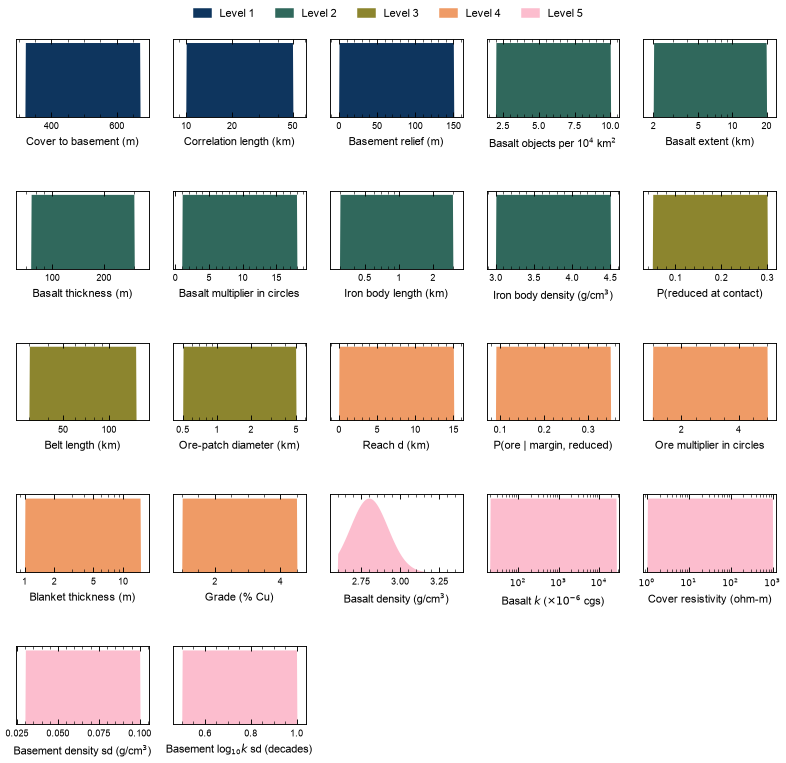

22 sampled quantities from 17 citation rows; each panel is checked against its row by cited()


In [7]:
PANELS = [("L1-1", "Cover to basement (m)", ("u", 320, 670)), ("L1-2", "Correlation length (km)", ("lu", 10, 50)),
          ("L1-3", "Basement relief (m)", ("u", 0, 150)), ("L2-1", "Basalt objects per 10$^4$ km$^2$", ("u", 2, 10)),
          ("L2-2", "Basalt extent (km)", ("lu", 2, 20)), ("L2-2", "Basalt thickness (m)", ("lu", 75, 300)),
          ("L2-3", "Basalt multiplier in circles", ("u", 1, 18)), ("L2-4", "Iron body length (km)", ("lu", 0.3, 3)),
          ("L3-1", "P(reduced at contact)", ("u", 0.05, 0.30)), ("L3-2", "Belt length (km)", ("lu", 30, 150)),
          ("L3-2", "Ore-patch diameter (km)", ("lu", 0.5, 5)), ("L4-1", "Reach d (km)", ("u", 0, 15)),
          ("L4-2", "P(ore | margin, reduced)", ("u", 0.09, 0.35)), ("L4-3", "Ore multiplier in circles", ("u", 1, 5)),
          ("L4-4", "Blanket thickness (m)", ("lu", 1, 15)), ("L4-4", "Grade (% Cu)", ("u", 1.0, 4.5)),
          ("L5-1", "Basalt density (g/cm$^3$)", ("tn", 2.80, 0.12, 2.60, 3.35)), ("L5-1", "Basalt $k$ ($\\times10^{-6}$ cgs)", ("lu", 20, 26000)),
          ("L5-2", "Cover resistivity (ohm-m)", ("lu", 1, 1000)), ("L5-4", "Basement density sd (g/cm$^3$)", ("u", 0.03, 0.10)),
          ("L2-4", "Iron body density (g/cm$^3$)", ("u", 3.0, 4.5)), ("L5-4", "Basement log$_{10}k$ sd (decades)", ("u", 0.5, 1.0))]
PANELS.sort(key=lambda t: (int(t[0][1]), t[0]))                   # in level order, rows within a level in table order
LEVEL_COL = {k: BATLOW(v) for k, v in zip(range(1, 6), (0.08, 0.30, 0.52, 0.74, 0.92))}   # batlow, as in the other figures
fig, axes = plt.subplots(5, 5, figsize=(COL2, 7.0))
fig.subplots_adjust(left=0.03, right=0.99, top=0.95, bottom=0.06, wspace=0.18, hspace=0.95)
for ax in axes.flat[len(PANELS):]: ax.axis("off")
for ax, (row, lab, dist) in zip(axes.flat, PANELS):
    c = LEVEL_COL[int(row[1])]
    if dist[0] == "u":
        a, b = dist[1], dist[2]; x = np.linspace(a - 0.08 * (b - a), b + 0.08 * (b - a), 300)
        y = ((x >= a) & (x <= b)) / (b - a); ax.fill_between(x, y, color=c, lw=0); ax.set_xlim(x[0], x[-1])
    elif dist[0] == "lu":
        a, b = dist[1], dist[2]; x = np.exp(np.linspace(np.log(a) - 0.2, np.log(b) + 0.2, 300))
        y = ((x >= a) & (x <= b)) / np.log(b / a); ax.fill_between(x, y, color=c, lw=0)
        ax.set_xscale("log"); ax.set_xlim(x[0], x[-1])
        if b / a > 200:
            tk = [10.0 ** n for n in range(-2, 7) if a <= 10.0 ** n <= b]; tl = [f"$10^{{{int(np.log10(v))}}}$" for v in tk]
        else:
            tk = [v for v in (0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500) if a <= v <= b]; tl = [f"{v:g}" for v in tk]
        ax.set_xticks(tk); ax.set_xticklabels(tl); ax.xaxis.set_minor_formatter(plt.NullFormatter())
    else:
        m, s, a, b = dist[1:]; x = np.linspace(a - 0.05, b + 0.05, 300)
        y = stats.truncnorm.pdf(x, (a - m) / s, (b - m) / s, loc=m, scale=s); ax.fill_between(x, y, color=c, lw=0)
        ax.set_xlim(x[0], x[-1])
    ax.set_yticks([]); ax.yaxis.set_minor_locator(plt.NullLocator()); ax.set_ylim(0, None)
    ax.set_xlabel(f"{lab}", fontsize=FS_ANNOT); ax.tick_params(labelsize=FS_ANNOT - 1)
h = [plt.Rectangle((0, 0), 1, 1, color=c, label=f"Level {k}") for k, c in LEVEL_COL.items()]
fig.legend(handles=h, loc="upper center", ncol=5, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.0))
fig.savefig(FIG / "wp4_PP_00_prior_distributions.png", dpi=300)
plt.show()
print(f"{len(PANELS)} sampled quantities from {CT.shape[0]} citation rows; each panel is checked against its row by cited()")


### How to read this figure

Flat blocks are uniform on a linear axis or log-uniform on a log axis (the translation rule: a range, not a mode, wherever the era document gave only bounds or words). Basalt density is the only shaped prior, from Risely's 15 measured specific gravities.


### Step 1. Level 1, stratigraphic frame (seed 43)

Every section in the notebook (here and Step 5) is the west to east line through the Olympic Dam northing, dashed in panel (a).


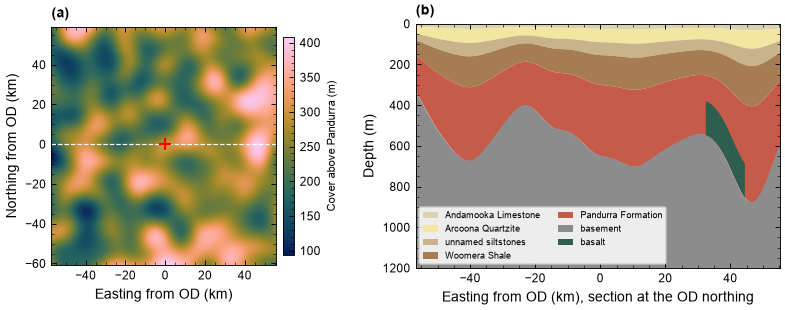

realization 43: cover to basement drawn 548 m (Stuart Shelf succession 93-409 m, Pandurra 110-480 m), relief 3 m, correlation length 10.7 km
depth to the top of basement 203-888 m


In [8]:
OUT, MAPS, OBJ, ORE = {}, {}, {}, {}
for s in (43, 77, 99):
    OUT[s], MAPS[s], OBJ[s], ORE[s] = realize(s, keep_volume=True)
S = 43; m = MAPS[S]; o = OUT[S]
iy = int(np.argmin(abs(YC - ODY)))                            # the west-east section passes the deposit's northing
ext = [(X0 - ODX) / 1e3, (X1 - ODX) / 1e3, (Y0 - ODY) / 1e3, (Y1 - ODY) / 1e3]
xkm = (XC - ODX) / 1e3
fig, axes = plt.subplots(1, 2, figsize=(COL2, 3.0), gridspec_kw={"width_ratios": [1, 1.5]})
fig.subplots_adjust(left=0.07, right=0.99, top=0.88, bottom=0.14, wspace=0.40)
ax = axes[0]
im = ax.imshow(m["cover"], origin="lower", extent=ext, cmap=BATLOW, aspect="equal")
ax.axhline(0, color="white", lw=0.8, ls="--")
ax.plot(0, 0, "+", color="red", ms=8, mew=1.4)
ax.set_xlabel("Easting from OD (km)"); ax.set_ylabel("Northing from OD (km)")
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03); cb.set_label("Cover above Pandurra (m)", fontsize=FS_ANNOT)
ax = axes[1]
UNIT_COL = {1: "#d9d2b5", 2: "#f2e6a0", 3: "#c9b38a", 4: "#a67c52", 5: "#c75b4a", 6: "#2e5e4e", 7: "#8c8c8c", 8: "#5b2c0e"}
tops = [np.zeros(NX), m["s1"][iy], m["s2"][iy], m["s3"][iy], m["cover"][iy], m["base"][iy]]
for code in range(1, 6):
    ax.fill_between(xkm, tops[code - 1], tops[code], color=UNIT_COL[code], lw=0, label=LITH[code])
ax.fill_between(xkm, m["base"][iy], 2000, color=UNIT_COL[7], lw=0, label=LITH[7])
bs = ~np.isnan(m["btop"][iy])
ax.fill_between(xkm, np.where(bs, m["btop"][iy], m["base"][iy]), m["base"][iy], where=bs, color=UNIT_COL[6], lw=0, label=LITH[6])
ax.invert_yaxis(); ax.set_ylim(1200, 0); ax.set_xlim(xkm[0], xkm[-1])
ax.set_xlabel("Easting from OD (km), section at the OD northing"); ax.set_ylabel("Depth (m)")
ax.legend(fontsize=FS_ANNOT - 1, loc="lower left", ncol=2, framealpha=0.85, frameon=True)
panel_labels(axes, ("(a)", "(b)"))
fig.savefig(FIG / "wp4_PP_01_level1_frame.png", dpi=300)
plt.show()
print(f"realization {S}: cover to basement drawn {o['L1-1 cover_total_m']:.0f} m (Stuart Shelf succession {m['cover'].min():.0f}-{m['cover'].max():.0f} m, "
      f"Pandurra {(m['base'] - m['cover']).min():.0f}-{(m['base'] - m['cover']).max():.0f} m), "
      f"relief {o['L1-3 relief_m']:.0f} m, correlation length {o['L1-2 corr_length_km']:.1f} km")
print(f"depth to the top of basement {m['base'].min():.0f}-{m['base'].max():.0f} m")


### How to read this figure

(a) The Stuart Shelf succession above the Pandurra, 0.46 of $c(\mathbf{x})$: 93 to 409 m around a drawn $T$ of 548 m, with an 11 km field. (b) The section: units by fixed share, Pandurra 0.54 of the total, relief 3 m (this seed draws almost none), basement at 335 to 877 m on the line. Dark green is Level 2 basalt, a 13 km pile on the contact at 32 to 44 km east.


### Step 2. Level 2, basalt objects and iron-oxide bodies


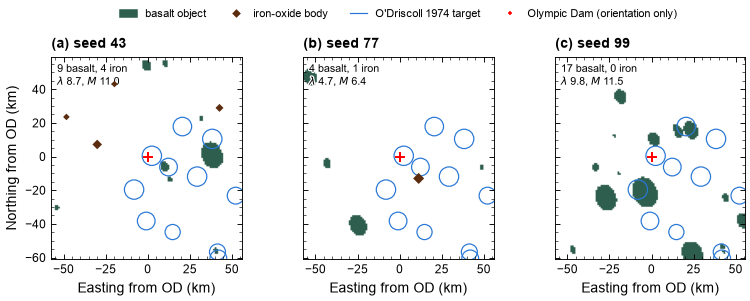

seed 43: 9 objects, 2 centred in a circle; extent 2.9-16.3 km, thickness 107-202 m, basalt covers 1.9% of the window; 4 iron-oxide bodies
seed 77: 4 objects, 0 centred in a circle; extent 3.3-12.8 km, thickness 132-251 m, basalt covers 1.4% of the window; 1 iron-oxide bodies
seed 99: 17 objects, 7 centred in a circle; extent 2.4-18.7 km, thickness 76-275 m, basalt covers 5.8% of the window; 0 iron-oxide bodies


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.7))
fig.subplots_adjust(left=0.07, right=0.99, top=0.82, bottom=0.14, wspace=0.12)
for ax, s in zip(axes, (43, 77, 99)):
    m = MAPS[s]
    ax.imshow(np.where(m["bid"] > 0, 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap(["#2e5e4e"]), aspect="equal")
    for x, y, rr in zip(TX, TYY, TG.radius_km.values):
        ax.add_patch(plt.Circle(((x - ODX) / 1e3, (y - ODY) / 1e3), rr, fill=False, ec="#2a78d6", lw=0.8))
    ir = pd.DataFrame(m["irons"])
    if len(ir): ax.scatter((ir.x - ODX) / 1e3, (ir.y - ODY) / 1e3, s=6 + 8 * ir.length_km, marker="D", c="#5b2c0e", edgecolors="none", zorder=4)
    ax.plot(0, 0, "+", color="red", ms=7, mew=1.3)
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_xlabel("Easting from OD (km)")
    o = OUT[s]; ax.text(0.03, 0.97, f"{o['n_basalt']} basalt, {o['n_iron']} iron\n$\\lambda$ {o['L2-1 intensity_per_1e4km2']:.1f}, $M$ {o['L2-3 basalt_multiplier']:.1f}",
                        transform=ax.transAxes, va="top", fontsize=FS_ANNOT, path_effects=HALO)
axes[0].set_ylabel("Northing from OD (km)")
for ax in axes[1:]: ax.set_yticklabels([])
panel_labels(axes, (f"(a) seed 43", f"(b) seed 77", f"(c) seed 99"))
h = [plt.Rectangle((0, 0), 1, 1, color="#2e5e4e", label="basalt object"),
     plt.Line2D([], [], color="#5b2c0e", marker="D", ls="", label="iron-oxide body"),
     plt.Line2D([], [], color="#2a78d6", lw=0.8, label="O'Driscoll 1974 target"),
     plt.Line2D([], [], color="red", marker="+", ls="", label="Olympic Dam (orientation only)")]
fig.legend(handles=h, loc="upper center", ncol=4, fontsize=FS_ANNOT, bbox_to_anchor=(0.53, 1.01))
fig.savefig(FIG / "wp4_PP_02_level2_basalt.png", dpi=300)
plt.show()
for s in (43, 77, 99):
    b = OBJ[s]
    print(f"seed {s}: {OUT[s]['n_basalt']} objects, {int(b.in_circle.sum()) if len(b) else 0} centred in a circle; "
          f"extent {b.length_km.min():.1f}-{b.length_km.max():.1f} km, thickness {b.thickness_m.min():.0f}-{b.thickness_m.max():.0f} m, "
          f"basalt covers {OUT[s]['basalt_frac']*100:.1f}% of the window; {OUT[s]['n_iron']} iron-oxide bodies" if len(b) else f"seed {s}: no objects")


### How to read this figure

Green is basalt, brown diamonds the iron-oxide bodies (4, 1 and 0), blue circles the 1974 targets, red cross Olympic Dam (orientation only). Seed 43 ($\lambda$ 8.7, $M$ 11.0): 9 piles, 2 centred in circles. Seed 77 (4.7, 6.4): 4 piles, none in a circle. Seed 99 (9.8, 11.5): 17 piles, 7 in circles. The multiplier row spans "lineaments do not matter" ($M = 1$) to "basalt mostly where O'Driscoll pointed" ($M = 18$).


### Step 3. Level 3, redox architecture


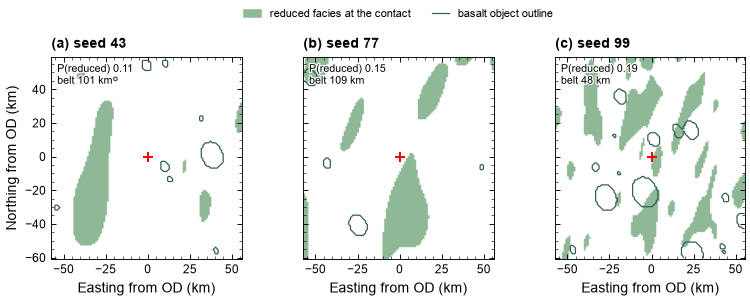

seed 43: P(reduced) drawn 0.106, realized 0.106; belt length 101 km (field correlation 34 by 10 km along 10 deg)
seed 77: P(reduced) drawn 0.148, realized 0.148; belt length 109 km (field correlation 36 by 11 km along 10 deg)
seed 99: P(reduced) drawn 0.192, realized 0.192; belt length 48 km (field correlation 16 by 5 km along 10 deg)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.7))
fig.subplots_adjust(left=0.07, right=0.99, top=0.82, bottom=0.14, wspace=0.12)
for ax, s in zip(axes, (43, 77, 99)):
    m = MAPS[s]
    ax.imshow(np.where(m["reduced"], 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap(["#8fb996"]), aspect="equal")
    ax.contour((XC - ODX) / 1e3, (YC - ODY) / 1e3, (m["bid"] > 0).astype(float), levels=[0.5], colors="#2e5e4e", linewidths=0.8)
    ax.plot(0, 0, "+", color="red", ms=7, mew=1.3)
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_xlabel("Easting from OD (km)")
    o = OUT[s]; ax.text(0.03, 0.97, f"P(reduced) {o['L3-1 p_reduced']:.2f}\nbelt {o['L3-2 belt_length_km']:.0f} km",
                        transform=ax.transAxes, va="top", fontsize=FS_ANNOT, path_effects=HALO)
axes[0].set_ylabel("Northing from OD (km)")
for ax in axes[1:]: ax.set_yticklabels([])
panel_labels(axes, (f"(a) seed 43", f"(b) seed 77", f"(c) seed 99"))
h = [plt.Rectangle((0, 0), 1, 1, color="#8fb996", label="reduced facies at the contact"),
     plt.Line2D([], [], color="#2e5e4e", lw=0.8, label="basalt object outline")]
fig.legend(handles=h, loc="upper center", ncol=2, fontsize=FS_ANNOT, bbox_to_anchor=(0.53, 1.01))
fig.savefig(FIG / "wp4_PP_03_level3_redox.png", dpi=300)
plt.show()
for s in (43, 77, 99):
    print(f"seed {s}: P(reduced) drawn {OUT[s]['L3-1 p_reduced']:.3f}, realized {OUT[s]['reduced_frac']:.3f}; "
          f"belt length {OUT[s]['L3-2 belt_length_km']:.0f} km (field correlation {OUT[s]['L3-2 belt_length_km']/3:.0f} by "
          f"{OUT[s]['L3-2 belt_length_km']/3/FIX['belt_aspect']:.0f} km along {FIX['belt_az']:.0f} deg)")


### How to read this figure

Pale green is reduced facies, outlines are basalt. Realized fractions equal the drawn $p$ (0.106, 0.148, 0.192) by construction of the threshold. Long belts (101 and 109 km, seeds 43 and 77) give a few bands; the short belt of seed 99 (48 km) gives many patches.


### Step 4. Level 4, ore rule


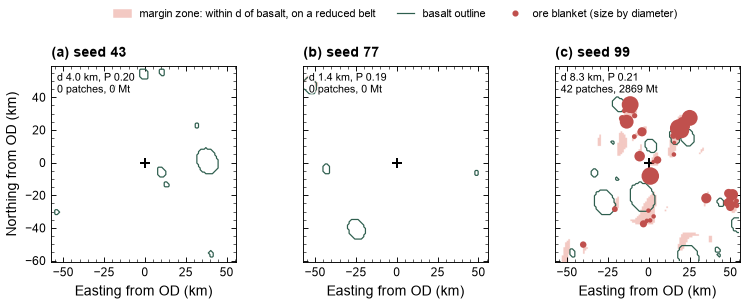

seed 43: margin zone 0 km2, 0 ore patches
seed 77: margin zone 27 km2, 0 ore patches
seed 99: margin zone 813 km2, 42 ore patches; blanket depth 163-633 m, thickness 1.0-14.4 m, grade 1.0-4.5%, largest patch 546.6 Mt


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.7))
fig.subplots_adjust(left=0.07, right=0.99, top=0.80, bottom=0.14, wspace=0.12)
for ax, s in zip(axes, (43, 77, 99)):
    m = MAPS[s]; e = ORE[s]
    ax.imshow(np.where(m["zone"], 1.0, np.nan), origin="lower", extent=ext, cmap=plt.matplotlib.colors.ListedColormap(["#f3c9c3"]), aspect="equal")
    ax.contour((XC - ODX) / 1e3, (YC - ODY) / 1e3, (m["bid"] > 0).astype(float), levels=[0.5], colors="#2e5e4e", linewidths=0.8)
    if len(e):
        ax.scatter((e.x - ODX) / 1e3, (e.y - ODY) / 1e3, s=4 + 6 * e.diam_km ** 2, c="#c0504d", edgecolors="none", zorder=4)
    ax.plot(0, 0, "+", color="black", ms=7, mew=1.3)
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_xlabel("Easting from OD (km)")
    o = OUT[s]; ax.text(0.03, 0.97, f"d {o['L4-1 reach_d_km']:.1f} km, P {o['L4-2 p_ore']:.2f}\n{o['n_ore']} patch{'es' if o['n_ore'] != 1 else ''}, {o['Mt_total']:.0f} Mt",
                        transform=ax.transAxes, va="top", fontsize=FS_ANNOT, path_effects=HALO)
axes[0].set_ylabel("Northing from OD (km)")
for ax in axes[1:]: ax.set_yticklabels([])
panel_labels(axes, (f"(a) seed 43", f"(b) seed 77", f"(c) seed 99"))
h = [plt.Rectangle((0, 0), 1, 1, color="#f3c9c3", label="margin zone: within d of basalt, on a reduced belt"),
     plt.Line2D([], [], color="#2e5e4e", lw=0.8, label="basalt outline"),
     plt.Line2D([], [], color="#c0504d", marker="o", ls="", label="ore blanket (size by diameter)")]
fig.legend(handles=h, loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.53, 1.02))
fig.savefig(FIG / "wp4_PP_04_level4_ore.png", dpi=300)
plt.show()
for s in (43, 77, 99):
    e = ORE[s]
    rng = lambda v, f: f"{v.min():{f}}" if len(v) == 1 else f"{v.min():{f}}-{v.max():{f}}"
    msg = (f"; blanket depth {rng(e.depth_m, '.0f')} m, thickness {rng(e.thick_m, '.1f')} m, "
           f"grade {rng(e.grade, '.1f')}%, largest patch {e.Mt.max():.1f} Mt" if len(e) else "")
    print(f"seed {s}: margin zone {OUT[s]['zone_km2']:.0f} km2, {OUT[s]['n_ore']} ore patch{'es' if OUT[s]['n_ore'] != 1 else ''}{msg}")


### How to read this figure

Pink is the margin zone $Z$, red dots ore blankets sized by diameter. Seed 43: $d$ = 4.0 km but no reduced cell within reach of a pile, so no zone and no ore. Seed 77: 27 km$^2$ ($d$ = 1.4 km around 4 piles), no patch. Seed 99: 813 km$^2$ ($d$ = 8.3 km around 17 piles), 42 patches, 2,869 Mt, 163 to 633 m deep. Ore needs basalt, reduced facies and reach to coincide, so most districts carry basalt and no ore.


### Step 5. Level 5, property volumes (seed 43, the section of Step 1)


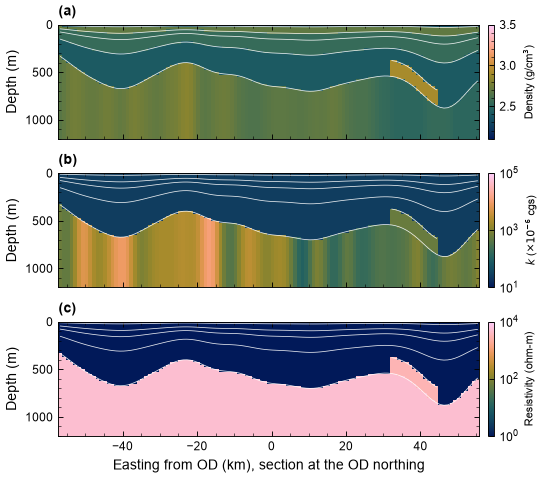

seed 43 unit densities: limestone 2.34, quartzite 2.70, shale and siltstone 2.55, Pandurra 2.42, basement field 2.50-2.93 (sd 0.097)
basement susceptibility field 10-20000 x 1e-6 cgs (log10 sd 0.95 decades; 30 km domains plus 4 km texture, 80% at the domain scale)
iron-oxide bodies: 4, density 3.05-4.22
basalt objects: density 2.74-3.08, k 294-22654
cover k 26, cover resistivity 1 ohm-m; basalt 3100, basement 5000


In [12]:
m = MAPS[43]
fig, axes = plt.subplots(3, 1, figsize=(COL15, 4.4), sharex=True)
fig.subplots_adjust(left=0.12, right=0.86, top=0.95, bottom=0.10, hspace=0.30)
zb = np.r_[0, np.cumsum(HZ[::-1][::-1])]                       # layer boundaries, top first
xb = np.r_[XC - DX / 2, XC[-1] + DX / 2]; xbk = (xb - ODX) / 1e3
for ax, key, lab, norm, cmap in [(axes[0], "rho", "Density (g/cm$^3$)", plt.matplotlib.colors.Normalize(2.1, 3.5), BATLOW),
                                  (axes[1], "k", "$k$ ($\\times10^{-6}$ cgs)", plt.matplotlib.colors.LogNorm(10, 1e5), BATLOW),
                                  (axes[2], "res", "Resistivity (ohm-m)", plt.matplotlib.colors.LogNorm(1, 1e4), BATLOW)]:
    sec = m[key][iy].T                                        # (nz, nx)
    pc = ax.pcolormesh(xbk, zb, sec, norm=norm, cmap=cmap, shading="flat", rasterized=True)
    for arr in (m["s1"][iy], m["s2"][iy], m["s3"][iy], m["cover"][iy], m["base"][iy]):            # the unit boundaries of Step 1 (b)
        ax.plot(xkm, arr, color="white", lw=0.5, alpha=0.9)
    bs = ~np.isnan(m["btop"][iy]); ax.plot(xkm, np.where(bs, m["btop"][iy], np.nan), color="white", lw=0.5, alpha=0.9)
    ax.set_ylim(1200, 0); ax.set_ylabel("Depth (m)")
    cb = fig.colorbar(pc, ax=ax, fraction=0.04, pad=0.02); cb.set_label(lab, fontsize=FS_ANNOT)
axes[-1].set_xlabel("Easting from OD (km), section at the OD northing")
axes[0].set_xlim(xbk[0], xbk[-1])
panel_labels(axes, ("(a)", "(b)", "(c)"))
fig.savefig(FIG / "wp4_PP_05_level5_properties.png", dpi=300)
plt.show()
o = OUT[43]
print(f"seed 43 unit densities: limestone {o['L5-2 rho_limestone']:.2f}, quartzite {o['L5-2 rho_quartzite']:.2f}, "
      f"shale and siltstone {o['L5-2 rho_shale']:.2f}, Pandurra {o['L5-2 rho_pandurra']:.2f}, basement field {m['rho_base'].min():.2f}-{m['rho_base'].max():.2f} (sd {o['L5-4 basement_sd']:.3f})")
print(f"basement susceptibility field {m['k_base'].min():.0f}-{m['k_base'].max():.0f} x 1e-6 cgs (log10 sd {o['L5-4 basement_logk_sd']:.2f} decades; "
      f"{FIX['domain_km']:.0f} km domains plus {FIX['texture_km']:.0f} km texture, {FIX['domain_share']*100:.0f}% at the domain scale)")
print(f"iron-oxide bodies: {o['n_iron']}, density {pd.DataFrame(m['irons']).rho.min():.2f}-{pd.DataFrame(m['irons']).rho.max():.2f}" if o["n_iron"] else "iron-oxide bodies: none in this realization")
if len(OBJ[43]): print(f"basalt objects: density {OBJ[43].rho.min():.2f}-{OBJ[43].rho.max():.2f}, k {OBJ[43].k.min():.0f}-{OBJ[43].k.max():.0f}")
print(f"cover k {o['L5-2 k_cover']:.0f}, cover resistivity {o['L5-2 res_cover']:.0f} ohm-m; basalt {FIX['res_basalt']:.0f}, basement {FIX['res_basement']:.0f}")
if len(ORE[43]): print(f"ore density increments {ORE[43].drho.min():.3f}-{ORE[43].drho.max():.3f} g/cm3 (grade {ORE[43].grade.min():.1f}-{ORE[43].grade.max():.1f}%)")


### How to read this figure

White lines are the Step 1 unit boundaries. (a) Density: the basalt pile at 32 to 44 km east (2.74 to 3.08 across seed 43's piles) against Pandurra 2.42; the basement field, 2.50 to 2.93 ($\sigma_\rho$ = 0.097), shows its 30 km domains as the slow east-west change below the unconformity; none of the four iron-oxide bodies (3.05 to 4.22) is on the line. (b) Susceptibility: cover 26, basalt 294 to 22,654, basement 10 to 20,000 x 1e-6 cgs from its own field ($\sigma_k$ = 0.95 decades). (c) Resistivity: cover 1 ohm-m (the bottom of the L5-2 range), basalt 3,100, basement 5,000.


### Step 6. Ensemble of 50, checked against its rows

Seeds 1000 to 1049; draws and summaries written to `wp4_prior_draws_n50.csv`.


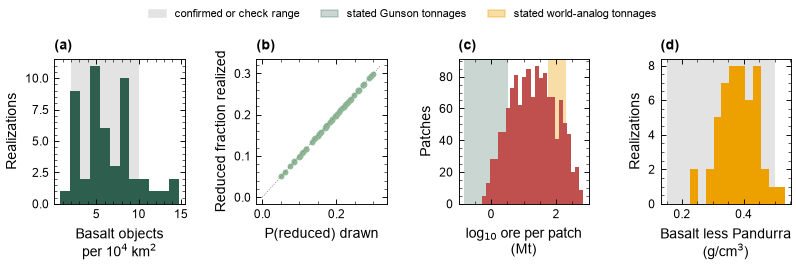

50 realizations; basalt objects per realization 1-20 (median 8); realizations with no basalt 0
reduced fraction realized minus drawn: max |diff| 0.000
ore patches per realization 0-122 (median 13); with no ore 7
ore per patch 0.53-674 Mt, median 19.5 Mt; 14% at or below the largest Gunson figure (3.2 Mt), 27.7% at or above the smallest world analog (57 Mt), 8.5% above the largest (198 Mt), 58% in the gap between the two
patches inside the 1974 circles: 19% (circles cover 6.6% of the window)
basalt less Pandurra density 0.23-0.53, median 0.38; inside 0.15-0.5: 98% of realizations with basalt
draws table written: wp4_prior_draws_n50.csv (50 rows, 29 columns)


In [13]:
N = 50
rows, all_ore = [], []
for s in range(1000, 1000 + N):
    o, _, b, e = realize(s)
    rows.append(o)
    if len(e): all_ore.append(e.assign(seed=s))
EN = pd.DataFrame(rows); ORES = pd.concat(all_ore, ignore_index=True) if all_ore else pd.DataFrame()
EN.to_csv(TAB / "wp4_prior_draws_n50.csv", index=False)
gun = [float(x) for x in re.findall(r"Gunson (\d+\.?\d*)-(\d+\.?\d*) Mt", CT.loc["L4-4", "evidence_and_translation"])[0]]
wld = [float(x) for x in re.findall(r"world (\d+)-(\d+) Mt", CT.loc["L4-4", "evidence_and_translation"])[0]]
fig, axes = plt.subplots(1, 4, figsize=(COL2, 2.4))
fig.subplots_adjust(left=0.06, right=0.99, top=0.80, bottom=0.25, wspace=0.55)
ax = axes[0]; ax.hist(EN.n_basalt / AREA_KM2 * 1e4, bins=12, color="#2e5e4e"); ax.axvspan(2, 10, color=ANNEX_GREY, zorder=0, lw=0)
ax.set_xlabel("Basalt objects\nper 10$^4$ km$^2$"); ax.set_ylabel("Realizations")
ax = axes[1]; ax.scatter(EN["L3-1 p_reduced"], EN.reduced_frac, s=8, color="#8fb996"); ax.plot([0, 0.32], [0, 0.32], color="0.5", lw=0.6, ls=":")
ax.set_xlabel("P(reduced) drawn\n"); ax.set_ylabel("Reduced fraction realized")
ax = axes[2]
if len(ORES): ax.hist(np.log10(ORES.Mt), bins=25, color="#c0504d")
ax.axvspan(np.log10(gun[0]), np.log10(gun[1]), color="#2e5e4e", alpha=0.25, lw=0, zorder=0)
ax.axvspan(np.log10(wld[0]), np.log10(wld[1]), color="#eda100", alpha=0.35, lw=0, zorder=0)
ax.set_xlabel("log$_{10}$ ore per patch\n(Mt)"); ax.set_ylabel("Patches")
ax = axes[3]; ax.hist(EN.contrast.dropna(), bins=12, color="#eda100"); ax.axvspan(0.15, 0.5, color=ANNEX_GREY, zorder=0, lw=0)
ax.set_xlabel("Basalt less Pandurra\n(g/cm$^3$)"); ax.set_ylabel("Realizations")
panel_labels(axes, ("(a)", "(b)", "(c)", "(d)"))
h = [plt.Rectangle((0, 0), 1, 1, color=ANNEX_GREY, label="confirmed or check range"),
     plt.Rectangle((0, 0), 1, 1, color="#2e5e4e", alpha=0.25, label="stated Gunson tonnages"),
     plt.Rectangle((0, 0), 1, 1, color="#eda100", alpha=0.35, label="stated world-analog tonnages")]
fig.legend(handles=h, loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.02))
fig.savefig(FIG / "wp4_PP_06_ensemble_checks.png", dpi=300)
plt.show()
print(f"{N} realizations; basalt objects per realization {EN.n_basalt.min()}-{EN.n_basalt.max()} (median {EN.n_basalt.median():.0f}); "
      f"realizations with no basalt {int((EN.n_basalt == 0).sum())}")
print(f"reduced fraction realized minus drawn: max |diff| {abs(EN.reduced_frac - EN['L3-1 p_reduced']).max():.3f}")
print(f"ore patches per realization {EN.n_ore.min()}-{EN.n_ore.max()} (median {EN.n_ore.median():.0f}); with no ore {int((EN.n_ore == 0).sum())}")
if len(ORES):
    print(f"ore per patch {ORES.Mt.min():.2f}-{ORES.Mt.max():.0f} Mt, median {ORES.Mt.median():.1f} Mt; "
          f"{(ORES.Mt <= gun[1]).mean()*100:.0f}% at or below the largest Gunson figure ({gun[1]} Mt), "
          f"{(ORES.Mt >= wld[0]).mean()*100:.1f}% at or above the smallest world analog ({wld[0]:.0f} Mt), "
          f"{(ORES.Mt > wld[1]).mean()*100:.1f}% above the largest ({wld[1]:.0f} Mt), "
          f"{((ORES.Mt > gun[1]) & (ORES.Mt < wld[0])).mean()*100:.0f}% in the gap between the two")
    print(f"patches inside the 1974 circles: {ORES.in_circle.mean()*100:.0f}% (circles cover {IN_CIRCLE.mean()*100:.1f}% of the window)")
print(f"basalt less Pandurra density {EN.contrast.min():.2f}-{EN.contrast.max():.2f}, median {EN.contrast.median():.2f}; "
      f"inside 0.15-0.5: {((EN.contrast >= 0.15) & (EN.contrast <= 0.5)).mean()*100:.0f}% of realizations with basalt")
print(f"draws table written: wp4_prior_draws_n50.csv ({EN.shape[0]} rows, {EN.shape[1]} columns)")


### How to read this figure

(a) Piles per 10,000 km$^2$ against the 2 to 10 row range; Poisson scatter takes some realizations outside it (1 to 20 piles, median 8). (b) Reduced fraction realized equals drawn. (c) Tonnage per patch against the Mount Gunson (0.15 to 3.2 Mt) and world-analog (57 to 198 Mt) clusters: median 19.5 Mt, 58% in the gap, 8.5% above 198 Mt; 7 of 50 realizations have no ore. (d) Basalt less Pandurra density, median 0.38, 98% inside the 0.15 to 0.5 that the era interpreters assumed.


### Step 7. The three prior models in 3D


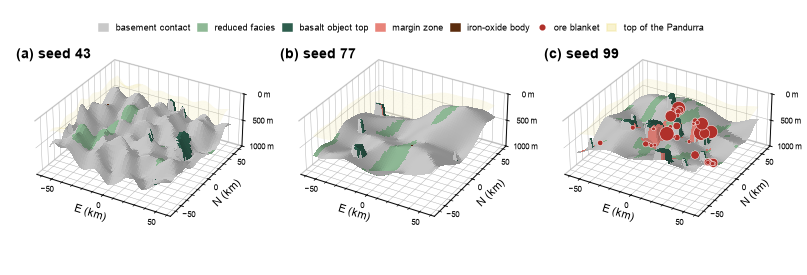

seed 43: 9 basalt objects, 4 iron-oxide bodies, reduced 11% of the contact, 0 ore blankets totalling 0 Mt; contact 203-888 m deep
seed 77: 4 basalt objects, 1 iron-oxide bodies, reduced 15% of the contact, 0 ore blankets totalling 0 Mt; contact 219-965 m deep
seed 99: 17 basalt objects, 0 iron-oxide bodies, reduced 19% of the contact, 42 ore blankets totalling 2869 Mt; contact 131-724 m deep


In [14]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.colors import LightSource, to_rgba
st = 2                                                        # plot every 2nd cell (2 km) for a readable surface
Xk, Yk = (GX[::st, ::st] - ODX) / 1e3, (GY[::st, ::st] - ODY) / 1e3
CAT = {0: "#c9c9c9", 1: "#8fb996", 2: "#2e5e4e", 3: "#e8847a", 4: "#5b2c0e"}
LS = LightSource(azdeg=315, altdeg=40)
fig = plt.figure(figsize=(COL2, 2.9))
fig.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.0, wspace=0.0)
for j, s in enumerate((43, 77, 99)):
    ax = fig.add_subplot(1, 3, j + 1, projection="3d", computed_zorder=False)
    ax.patch.set_alpha(0.0)                                   # transparent so a neighbour's tick labels are not hidden
    m = MAPS[s]; e = ORE[s]
    cat = np.zeros((NY, NX), int); cat[m["reduced"]] = 1; cat[m["bid"] > 0] = 2; cat[m["zone"]] = 3; cat[m["iid"] > 0] = 4
    cat = cat[::st, ::st]; zc = -m["contact"][::st, ::st]
    rgb = np.array([to_rgba(CAT[c]) for c in range(5)])[cat]
    hs = LS.hillshade(zc, vert_exag=20, dx=st, dy=st)[..., None]
    rgb[..., :3] *= 0.70 + 0.30 * hs
    ax.plot_surface(Xk, Yk, -m["cover"][::st, ::st], color="#f2e6a0", alpha=0.20, linewidth=0, shade=False, zorder=1)
    ax.plot_surface(Xk, Yk, zc, facecolors=rgb, rstride=1, cstride=1, linewidth=0, antialiased=False, shade=False, zorder=2)
    if len(e):
        ax.scatter((e.x - ODX) / 1e3, (e.y - ODY) / 1e3, -e.depth_m + 20, s=3 + 4 * e.diam_km ** 2, c="#b0302a",
                   edgecolors="white", linewidths=0.3, depthshade=False, zorder=5)
    ax.set_zlim(-1000, 0); ax.set_box_aspect((1, 1, 0.40), zoom=0.82); ax.view_init(elev=30, azim=-60)
    for a in (ax.xaxis, ax.yaxis, ax.zaxis):
        a.pane.set_facecolor((1, 1, 1, 0)); a.pane.set_edgecolor("0.75"); a._axinfo["grid"]["linewidth"] = 0.3
    ax.set_xticks([-50, 0, 50]); ax.set_yticks([-50, 0, 50])
    ax.set_xlabel("E (km)", fontsize=FS_ANNOT, labelpad=-8); ax.set_ylabel("N (km)", fontsize=FS_ANNOT, labelpad=-8)
    ax.tick_params(labelsize=FS_ANNOT - 2, pad=-3); ax.tick_params(axis="z", pad=1)
    ax.set_zticks([-1000, -500, 0]); ax.set_zticklabels(["1000 m", "500 m", "0 m"])
    ax.text2D(0.04, 0.80, f"({'abc'[j]}) seed {s}", transform=ax.transAxes, fontsize=FS_PANEL, fontweight="bold")
h = [plt.Rectangle((0, 0), 1, 1, color=CAT[0], label="basement contact"), plt.Rectangle((0, 0), 1, 1, color=CAT[1], label="reduced facies"),
     plt.Rectangle((0, 0), 1, 1, color=CAT[2], label="basalt object top"), plt.Rectangle((0, 0), 1, 1, color=CAT[3], label="margin zone"),
     plt.Rectangle((0, 0), 1, 1, color=CAT[4], label="iron-oxide body"),
     plt.Line2D([], [], color="#b0302a", marker="o", ls="", label="ore blanket"),
     plt.Rectangle((0, 0), 1, 1, color="#f2e6a0", alpha=0.5, label="top of the Pandurra")]
fig.legend(handles=h, loc="upper center", ncol=7, fontsize=FS_ANNOT - 1, bbox_to_anchor=(0.5, 0.88), handlelength=1.0, columnspacing=0.8, frameon=False)
fig.savefig(FIG / "wp4_PP_07_three_prior_models_3d.png", dpi=300)
plt.show()
for s in (43, 77, 99):
    o = OUT[s]
    print(f"seed {s}: {o['n_basalt']} basalt objects, {o['n_iron']} iron-oxide bodies, reduced {o['reduced_frac']*100:.0f}% of the contact, "
          f"{o['n_ore']} ore blanket{'s' if o['n_ore'] != 1 else ''} totalling {o['Mt_total']:.0f} Mt; contact {MAPS[s]['contact'].min():.0f}-{MAPS[s]['contact'].max():.0f} m deep")


### How to read this figure

Basement contact (raised to the basalt top where basalt is present) seen from the south-east, vertical exaggeration about 40. Green is reduced facies, salmon the margin zone, brown the iron-oxide bodies, red dots ore, yellow the top of the Pandurra. Seed 43: contact 203 to 888 m, no ore. Seed 77: 219 to 965 m, no ore. Seed 99: 131 to 724 m, 2,869 Mt.


## Section 4. Prior predictive check

A recipe can be wrong in a way no single row reveals, so the assembled sampler is checked as a whole: realizations are forward-modelled, sampled where the 1969 stations and 1962 flight lines were, and the statistics of their anomaly populations are compared with the real surveys. The check is a gate, diagnostic only. Nothing here feeds back into a row; a mismatch goes back to the levels as a numbered change to the citation table.


### Step 8. Observed surveys and the anomaly rule

The observed data are opened here for the first time: 342 BMR gravity stations (1969) and the P234 aeromagnetic lines (1962, 1.6 km spacing, 150 m clearance, every fourth reading). The rule is fixed in `RULE` before any observed statistic is computed. For a survey $v$ at points $\mathbf{x}_i$: remove the least-squares plane, grid the residual linearly onto the 1 km mesh, and call an anomaly any connected group of at least 3 cells above $T$ = 2 mGal or 20 nT. Five statistics per survey: anomalies per $10^4$ km$^2$, median peak, 90th-percentile peak, median width $w = 2\sqrt{a/\pi}$ from the anomaly area $a$, and the residual sd. Synthetic data get Gaussian noise: gravity from the station accuracy columns, $\sigma_g^2 = \sigma_{obs}^2 + (0.197\ \text{mGal/m} \times 5\ \text{m})^2$, about 1.0 mGal; magnetics a declared 5 nT.


In [15]:
from scipy.spatial import Delaunay
from scipy.interpolate import LinearNDInterpolator, RegularGridInterpolator

PM = Path(".")                                               # this notebook sits in the SVOI_OD folder
OBS = PM / "04_prior_predictive_observed"

# ---- the anomaly rule: fixed here, before any observed statistic is computed ------------------------------------------
RULE = dict(T_grav_mgal=2.0,          # anomaly threshold, twice the station noise (about 1 mGal, below)
            T_mag_nt=20.0,            # anomaly threshold, four times the declared 1962 reading noise
            mag_noise_nt=5.0,         # declared white noise on the 1962 readings
            min_cells=3,              # an anomaly is at least 3 connected 1 km cells (3 km2)
            mag_decimate=4,           # every 4th reading along line (about 270 m)
            elev_gradient=0.1967)     # Bouguer elevation factor, mGal/m at 2.67 g/cm3
FIELD = dict(F_nt=57776.0, inc=-62.44, dec=6.00, clearance_m=150.0)   # April 1962 field at the deposit (DGRF); P234 clearance
N_ENS, SEED0 = 200, 1000

# ---- observed: 342 BMR stations (1969) and the P234 lines (1962) in the regional window -------------------------------
gv = pd.read_csv(OBS / "gravity_stations_pre1975_regional.csv")
GXo, GYo = to_mga.transform(gv.LONGITUDE.values, gv.LATITUDE.values)
G_OBS = gv.SPHERICAL_CAP_BOUGUER_ANOMALY.values / 10.0                  # um/s2 to mGal
G_SD = np.sqrt((gv.ACCURACY_OF_OBSERVED_GRAVITY.values / 10.0) ** 2 + (RULE["elev_gradient"] * gv.ACCURACY_OF_GEOID_GND_ELEV.values) ** 2)
# P234 lines: read the .npz cache when present, so netCDF4 (a common cause of Windows kernel crashes) is not needed
CACHE = OBS / "P234-line-magnetic-AWAGS_MAG_2010_cache.npz"
if CACHE.exists():
    z = np.load(CACHE); lon, lat, mag, line = z["lon"], z["lat"], z["mag"], z["line"]
else:
    import netCDF4
    with netCDF4.Dataset(OBS / "P234-line-magnetic-AWAGS_MAG_2010.nc") as ds:
        lon, lat = np.asarray(ds["longitude"][:], float), np.asarray(ds["latitude"][:], float)
        mag = np.ma.filled(ds["mag_awagsLevelled"][:].astype(float), np.nan); line = np.asarray(ds["line_index"][:])
    np.savez_compressed(CACHE, lon=lon, lat=lat, mag=mag, line=line)
w = (lon >= WIN.lon_min) & (lon <= WIN.lon_max) & (lat >= WIN.lat_min) & (lat <= WIN.lat_max) & np.isfinite(mag)
idx = np.flatnonzero(w)[::RULE["mag_decimate"]]
MXo, MYo = to_mga.transform(lon[idx], lat[idx]); M_OBS = mag[idx]; M_LINE = line[idx]
print(f"gravity: {len(G_OBS)} stations, noise sd {np.median(G_SD):.2f} mGal (observed gravity 0.2 mGal, elevation 5 m)")
print(f"magnetics: {w.sum():,} readings on {len(np.unique(line[w]))} line segments in the window, {len(M_OBS):,} used")
print("rule:", RULE); print("field:", FIELD)


gravity: 342 stations, noise sd 1.00 mGal (observed gravity 0.2 mGal, elevation 5 m)
magnetics: 99,920 readings on 128 line segments in the window, 24,980 used
rule: {'T_grav_mgal': 2.0, 'T_mag_nt': 20.0, 'mag_noise_nt': 5.0, 'min_cells': 3, 'mag_decimate': 4, 'elev_gradient': 0.1967}
field: {'F_nt': 57776.0, 'inc': -62.44, 'dec': 6.0, 'clearance_m': 150.0}


### Reading the output

Gravity noise is dominated by the 5 m elevation accuracy. 24,980 magnetic readings are used.


### Step 9. Forward operator and its check against SimPEG

Layer by layer in the wavenumber domain, with $\tilde\rho_l$ and $\tilde M_l$ the 2D transforms of the density and magnetization contrasts of layer $l$ (top $a_l$, bottom $b_l$), $k = |\mathbf{k}|$:

$$\tilde g(\mathbf{k}) = 2\pi G \sum_l \tilde\rho_l\,\frac{e^{-k a_l} - e^{-k b_l}}{k}, \qquad
\tilde T(\mathbf{k}) = 2\pi \cdot 10^{-7}\,\Theta^2 \sum_l \tilde M_l \left(e^{-k(a_l + h)} - e^{-k(b_l + h)}\right),$$

gravity at the ground, total-field anomaly at $h$ = 150 m, $\Theta = f_z + i(f_x k_x + f_y k_y)/k$ for induced magnetization along the April 1962 field (F 57,776 nT, I -62.44 deg, D 6.00 deg), $M = 4\pi \cdot 10^{-6} k_{cgs}\, F/\mu_0$. About 0.25 s per realization. Checked against SimPEG's integral solution for a 6 x 6 km block 400 to 600 m deep.


In [16]:
# ---- layer-by-layer FFT forward operator on the sampler mesh (Blakely 1995, eqs 11.35 and 11.44 form) -------------------
PADN = 256
PY, PX = (PADN - NY) // 2, (PADN - NX) // 2
KX, KY = np.meshgrid(2 * np.pi * np.fft.fftfreq(PADN, DX), 2 * np.pi * np.fft.fftfreq(PADN, DX))
K = np.hypot(KX, KY); K[0, 0] = 1e-12
ZT = np.r_[0.0, np.cumsum(HZ[:-1])]; ZB = np.cumsum(HZ)                 # layer tops and bottoms (m), top first
I, D = np.radians(FIELD["inc"]), np.radians(FIELD["dec"])
fx, fy, fz = np.cos(I) * np.sin(D), np.cos(I) * np.cos(D), np.sin(I)    # east, north, down
THETA2 = (fz + 1j * (fx * KX + fy * KY) / K) ** 2                        # induced: magnetization parallel to the field
h = FIELD["clearance_m"]
EG = [(np.exp(-K * a) - np.exp(-K * b)) / K for a, b in zip(ZT, ZB)]
EM = [np.exp(-K * (a + h)) - np.exp(-K * (b + h)) for a, b in zip(ZT, ZB)]
GCONST, MU0 = 6.674e-11, 4e-7 * np.pi

def pad(a):
    return np.pad(a, ((PY, PADN - NY - PY), (PX, PADN - NX - PX)), mode="reflect")

def forward(rho, k_cgs):
    """gravity at the ground (mGal) and total-field anomaly at 150 m (nT) on the map grid, from (NY, NX, NZ) volumes"""
    g = np.zeros((PADN, PADN), complex); t = np.zeros((PADN, PADN), complex)
    M = k_cgs * 1e-6 * 4 * np.pi * FIELD["F_nt"] * 1e-9 / MU0            # cgs susceptibility to SI, induced magnetization (A/m)
    for l in range(rho.shape[2]):
        r, m = rho[:, :, l], M[:, :, l]
        if np.ptp(r) > 0: g += np.fft.fft2(pad(r - r.mean())) * EG[l]
        if np.ptp(m) > 0: t += np.fft.fft2(pad(m - m.mean())) * EM[l]
    g *= 2 * np.pi * GCONST * 1000.0 * 1e5; t *= 2 * np.pi * 1e-7 * THETA2 * 1e9
    g[0, 0] = t[0, 0] = 0
    crop = (slice(PY, PY + NY), slice(PX, PX + NX))
    return np.real(np.fft.ifft2(g))[crop], np.real(np.fft.ifft2(t))[crop]

# ---- the same statistics on observed and synthetic data -------------------------------------------------------------------
TRI_G, TRI_M = Delaunay(np.c_[GXo, GYo]), Delaunay(np.c_[MXo, MYo])

def detrend(x, y, v):
    A = np.c_[np.ones_like(x), (x - X0) / 1e3, (y - Y0) / 1e3]
    return v - A @ np.linalg.lstsq(A, v, rcond=None)[0]

def anomaly_stats(tri, x, y, v, T):
    res = detrend(x, y, v)
    grid = LinearNDInterpolator(tri, res)(GX, GY)
    ok = np.isfinite(grid)
    lab, n = ndimage.label(ok & (grid >= T), structure=np.ones((3, 3)))
    size = ndimage.sum(np.ones_like(grid), lab, np.arange(1, n + 1)); keep = size >= RULE["min_cells"]
    peak = np.asarray(ndimage.maximum(np.where(ok, grid, -np.inf), lab, np.arange(1, n + 1)))[keep]
    width = 2 * np.sqrt(size[keep] / np.pi)                              # km, cells are 1 km2
    s = dict(n_per_1e4km2=keep.sum() / ok.sum() * 1e4, amp_median=np.median(peak) if len(peak) else np.nan,
             amp_p90=np.percentile(peak, 90) if len(peak) else np.nan, width_median_km=np.median(width) if len(width) else np.nan,
             residual_sd=res.std())
    return s, grid, np.isin(lab, np.flatnonzero(keep) + 1)

def sample(field, x, y):
    return RegularGridInterpolator((YC, XC), field, bounds_error=False, fill_value=None)(np.c_[y, x])

def synthetic(seed, rng_noise=True):
    out, maps, objs, ores = realize(seed, keep_volume=True)
    g, t = forward(maps["rho"], maps["k"])
    r = np.random.default_rng(seed + 10_000_000)
    gs = sample(g, GXo, GYo) + (r.normal(0, G_SD) if rng_noise else 0)
    ms = sample(t, MXo, MYo) + (r.normal(0, RULE["mag_noise_nt"], len(MXo)) if rng_noise else 0)
    return out, maps, g, t, gs, ms

OBS_G, GRID_G, ANOM_G = anomaly_stats(TRI_G, GXo, GYo, G_OBS, RULE["T_grav_mgal"])
OBS_M, GRID_M, ANOM_M = anomaly_stats(TRI_M, MXo, MYo, M_OBS, RULE["T_mag_nt"])
print("forward operator ready:", PADN, "x", PADN, "padded grid,", len(ZT), "layers")

# ---- check the FFT operator against SimPEG's integral solution for one test body ---------------------------------------
try:
    import simpeg
    from simpeg import maps as smaps
    from simpeg.potential_fields import gravity as sgrav, magnetics as smag
    HAVE_SIMPEG = True
except ImportError:
    HAVE_SIMPEG = False
    print("simpeg not installed: the operator check against SimPEG is skipped (it was passed on 2026-09-22)")
if HAVE_SIMPEG:
    jc, ic = NY // 2, NX // 2; L1, L2 = 16, 24                            # a 6 x 6 km block, 400 to 600 m deep
    rho_t = np.zeros((NY, NX, len(ZC))); k_t = np.zeros_like(rho_t)
    rho_t[jc - 3:jc + 3, ic - 3:ic + 3, L1:L2] = 0.30                        # g/cm3
    k_t[jc - 3:jc + 3, ic - 3:ic + 3, L1:L2] = 10000.0                       # 1e-6 cgs
    g_fft, t_fft = forward(rho_t, k_t)
    bm = discretize.TensorMesh([[DX] * 6, [DX] * 6, [25.0] * (L2 - L1)], origin=[XC[ic - 3] - DX / 2, YC[jc - 3] - DX / 2, -ZB[L2 - 1]])
    rx_xy = np.c_[GX.ravel(), GY.ravel()]
    sv_g = sgrav.survey.Survey(sgrav.sources.SourceField([sgrav.receivers.Point(np.c_[rx_xy, np.zeros(len(rx_xy))], components="gz")]))
    sim_g = sgrav.simulation.Simulation3DIntegral(bm, survey=sv_g, rhoMap=smaps.IdentityMap(nP=bm.n_cells), active_cells=np.ones(bm.n_cells, bool), store_sensitivities="forward_only")
    g_sp = -sim_g.dpred(np.full(bm.n_cells, 0.30)).reshape(NY, NX)     # SimPEG gz is positive up; the FFT operator is positive down
    rx_m = smag.receivers.Point(np.c_[rx_xy, np.full(len(rx_xy), h)], components="tmi")
    src_m = smag.sources.UniformBackgroundField(receiver_list=[rx_m], amplitude=FIELD["F_nt"], inclination=FIELD["inc"], declination=FIELD["dec"])
    sim_m = smag.simulation.Simulation3DIntegral(bm, survey=smag.survey.Survey(src_m), chiMap=smaps.IdentityMap(nP=bm.n_cells), active_cells=np.ones(bm.n_cells, bool), store_sensitivities="forward_only")
    t_sp = sim_m.dpred(np.full(bm.n_cells, 10000.0 * 1e-6 * 4 * np.pi)).reshape(NY, NX)
    g_sp_d, t_sp_d = g_sp - g_sp.mean(), t_sp - t_sp.mean()               # the FFT field has its mean removed; compare like with like
    g_ff_d, t_ff_d = g_fft - g_fft.mean(), t_fft - t_fft.mean()
    TEST_ERR = dict(grav_peak_ratio=g_ff_d.max() / g_sp_d.max(), grav_rms_rel=np.sqrt(np.mean((g_ff_d - g_sp_d) ** 2)) / np.ptp(g_sp_d),
                    mag_peak_ratio=t_ff_d.max() / t_sp_d.max(), mag_trough_ratio=t_ff_d.min() / t_sp_d.min(),
                    mag_rms_rel=np.sqrt(np.mean((t_ff_d - t_sp_d) ** 2)) / np.ptp(t_sp_d))
    print(f"SimPEG {simpeg.__version__}: test block 6 x 6 km, 400-600 m, +0.30 g/cm3 and 10,000 x 1e-6 cgs")
    print(f"gravity peak {g_sp_d.max():.2f} mGal (SimPEG) vs {g_ff_d.max():.2f} (FFT); magnetics {t_sp_d.min():.0f} to {t_sp_d.max():.0f} nT vs {t_ff_d.min():.0f} to {t_ff_d.max():.0f}")
    print({k: round(float(v), 3) for k, v in TEST_ERR.items()})

    fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.5))
    fig.subplots_adjust(left=0.08, right=0.99, top=0.84, bottom=0.2, wspace=0.3)
    xk = (XC - XC[ic]) / 1e3; yk = (YC - YC[jc]) / 1e3
    axes[0].plot(xk, g_sp_d[jc], color="0.3", lw=2.4, label="SimPEG integral")
    axes[0].plot(xk, g_ff_d[jc], color="#c0504d", lw=1.0, ls="--", label="FFT layer operator")
    axes[0].set_xlabel("Easting from block centre (km)"); axes[0].set_ylabel("Gravity (mGal)")
    axes[1].plot(yk, t_sp_d[:, ic], color="0.3", lw=2.4); axes[1].plot(yk, t_ff_d[:, ic], color="#c0504d", lw=1.0, ls="--")
    axes[1].set_xlabel("Northing from block centre (km)"); axes[1].set_ylabel("Total-field anomaly (nT)")
    for ax in axes: ax.set_xlim(-25, 25); ax.axvspan(-3, 3, color=ANNEX_GREY, zorder=0, lw=0)
    panel_labels(axes, ("(a) gravity, west-east", "(b) magnetics, south-north"))
    fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=2, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.02), frameon=False)
    fig.savefig(FIG / "wp4_PP_08_forward_check.png", dpi=300)
    plt.show()


forward operator ready: 256 x 256 padded grid, 90 layers
simpeg not installed: the operator check against SimPEG is skipped (it was passed on 2026-09-22)


### How to read this figure

Grey is SimPEG, red dashed the FFT operator, grey band the block. Gravity agrees to 0.1% RMS of the anomaly range with matching peaks (2.12 mGal); magnetics to 0.3% RMS, the FFT peak and trough about 9% high at the block edges (1 km cells). The negative lobe lies to the south, as induced magnetization at -62 deg requires.


### Step 10. Observed surveys against one realization (seed 43)


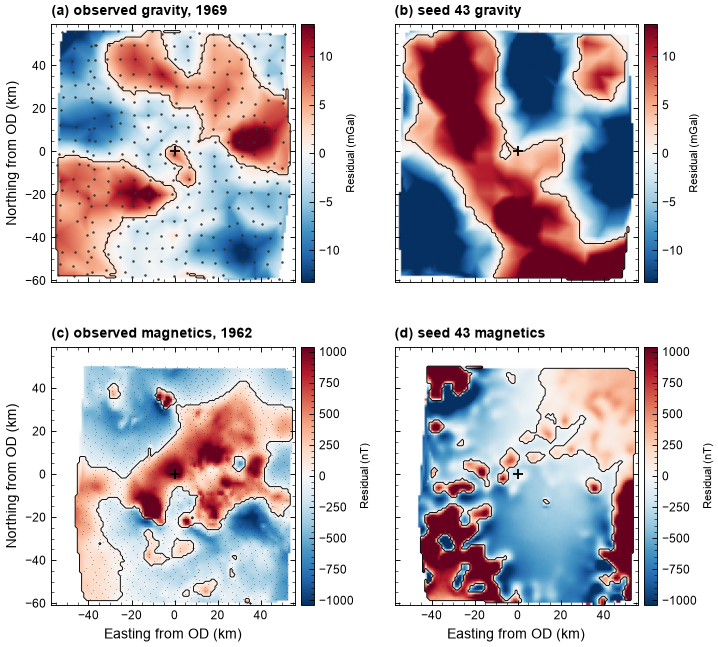

gravity   observed {'n_per_1e4km2': 4.1, 'amp_median': 8.04, 'amp_p90': 20.37, 'width_median_km': 13.49, 'residual_sd': 6.49}
          seed 43  {'n_per_1e4km2': 1.64, 'amp_median': 21.33, 'amp_p90': 29.21, 'width_median_km': 54.68, 'residual_sd': 13.04}
magnetics observed {'n_per_1e4km2': 9.35, 'amp_median': 398.08, 'amp_p90': 3127.72, 'width_median_km': 7.3, 'residual_sd': 475.5}
          seed 43  {'n_per_1e4km2': 14.03, 'amp_median': 1071.58, 'amp_p90': 3124.46, 'width_median_km': 6.48, 'residual_sd': 790.63}


In [17]:
out43, maps43, g43, t43, gs43, ms43 = synthetic(43)
SYN_G43, SGRID_G, SANOM_G = anomaly_stats(TRI_G, GXo, GYo, gs43, RULE["T_grav_mgal"])
SYN_M43, SGRID_M, SANOM_M = anomaly_stats(TRI_M, MXo, MYo, ms43, RULE["T_mag_nt"])
fig, axes = plt.subplots(2, 2, figsize=(COL2, 6.0))
fig.subplots_adjust(left=0.08, right=0.9, top=0.95, bottom=0.07, wspace=0.12, hspace=0.25)
lim_g = np.nanpercentile(abs(GRID_G), 98); lim_m = np.nanpercentile(abs(GRID_M), 98)
for ax, grid, anom, lim, lab in [(axes[0, 0], GRID_G, ANOM_G, lim_g, "mGal"), (axes[0, 1], SGRID_G, SANOM_G, lim_g, "mGal"),
                                  (axes[1, 0], GRID_M, ANOM_M, lim_m, "nT"), (axes[1, 1], SGRID_M, SANOM_M, lim_m, "nT")]:
    im = ax.imshow(grid, origin="lower", extent=ext, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="equal")
    ax.contour(xkm, (YC - ODY) / 1e3, anom.astype(float), levels=[0.5], colors="k", linewidths=0.6)
    ax.plot(0, 0, "+", color="k", ms=7, mew=1.2); ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
    cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02); cb.set_label(f"Residual ({lab})", fontsize=FS_ANNOT)
axes[0, 0].plot((GXo - ODX) / 1e3, (GYo - ODY) / 1e3, ".", color="0.2", ms=1.2)
axes[1, 0].plot((MXo[::20] - ODX) / 1e3, (MYo[::20] - ODY) / 1e3, ",", color="0.2", alpha=0.4)
for ax in axes[1]: ax.set_xlabel("Easting from OD (km)")
for ax in axes[:, 0]: ax.set_ylabel("Northing from OD (km)")
for ax in axes[:, 1]: ax.set_yticklabels([])
for ax in axes[0]: ax.set_xticklabels([])
panel_labels(axes.ravel(), ("(a) observed gravity, 1969", "(b) seed 43 gravity", "(c) observed magnetics, 1962", "(d) seed 43 magnetics"))
fig.savefig(FIG / "wp4_PP_09_observed_vs_seed43.png", dpi=300)
plt.show()
show = lambda s: {k: round(float(v), 2) for k, v in s.items()}
print("gravity   observed", show(OBS_G)); print("          seed 43 ", show(SYN_G43))
print("magnetics observed", show(OBS_M)); print("          seed 43 ", show(SYN_M43))


### How to read this figure

Residuals after the plane, same colour scale per row; black outlines are the detected anomalies. (a) Observed gravity: broad highs and lows of 10 to 15 mGal over tens of km. (b) Seed 43: the same kind of highs and lows from the basement field (this seed draws $\sigma_\rho$ = 0.097, the top of its range) in 30 km domains wider than the observed (55 km against 13), with the piles as sharper highs on top. (c) Observed magnetics: a broad high through the centre with peaks over 1,000 nT. (d) Seed 43: the piles on the two-scale basement field through 200 to 890 m of cover; a wide susceptibility spread (0.95 decades) makes its residual stronger than the survey's. Residual sd: gravity 6.5 mGal observed, 13.0 for seed 43; magnetics 476 nT against 791.


### Step 11. The predictive ensemble

200 realizations (seeds 1000 to 1199), each forward-modelled, sampled at the real station and line positions, given noise, and scored with the same rule. Written to `wp4_prior_predictive_stats_n200.csv`.


In [18]:
import time
t0 = time.time(); rows = []; PROF_G, PROF_M = [], []
for s in range(SEED0, SEED0 + N_ENS):
    o, mp, g, t, gs, ms = synthetic(s)
    sg, gg, _ = anomaly_stats(TRI_G, GXo, GYo, gs, RULE["T_grav_mgal"]); sm, gm, _ = anomaly_stats(TRI_M, MXo, MYo, ms, RULE["T_mag_nt"])
    rows.append({**{k: v for k, v in o.items()}, **{"g_" + k: v for k, v in sg.items()}, **{"m_" + k: v for k, v in sm.items()}})
    PROF_G.append(gg[iy]); PROF_M.append(gm[iy])                       # west-east profiles at the OD northing, for Step 14
PROF_G, PROF_M = np.array(PROF_G), np.array(PROF_M)
PP = pd.DataFrame(rows); PP.to_csv(TAB / "wp4_prior_predictive_stats_n200.csv", index=False)
np.savez_compressed(TAB / "wp4_prior_predictive_profiles_n200.npz", PROF_G=PROF_G, PROF_M=PROF_M, xkm=xkm)   # Step 14 input, kept with the stats
print(f"{N_ENS} realizations (seeds {SEED0}-{SEED0 + N_ENS - 1}) forward-modelled and scored in {time.time() - t0:.0f} s")
print("written: wp4_prior_predictive_stats_n200.csv", PP.shape)


200 realizations (seeds 1000-1199) forward-modelled and scored in 204 s
written: wp4_prior_predictive_stats_n200.csv (200, 39)


### Reading the output

About 80 s for the 200 realizations.


### Step 12. The gate

Each statistic is scored by the quantile $q$ of the observed value in the ensemble: PASS for $0.05 \le q \le 0.95$, WARN outside that but inside the ensemble range, FAIL outside the range. Written to `wp4_prior_predictive_gate.csv`.


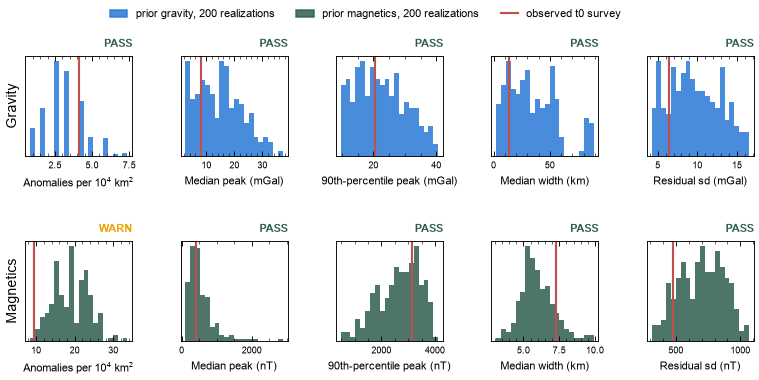

    field       statistic  observed  sim_p05  sim_median  sim_p95  sim_min  sim_max  quantile status
  gravity    n_per_1e4km2     4.101    0.820       3.281    5.741    0.820    7.381     0.802   PASS
  gravity      amp_median     8.043    3.708      14.873   28.623    2.509   37.267     0.230   PASS
  gravity         amp_p90    20.374   10.842      21.449   36.558    9.623   40.607     0.450   PASS
  gravity width_median_km    13.493    6.256      30.753   82.123    2.257   88.841     0.190   PASS
  gravity     residual_sd     6.485    4.934       9.331   14.876    4.217   16.507     0.180   PASS
magnetics    n_per_1e4km2     9.352   12.157      18.704   26.232    8.417   33.667     0.005   WARN
magnetics      amp_median   398.080  183.550     436.385 1244.378  106.011 2885.147     0.415   PASS
magnetics         amp_p90  3127.721 1223.301    2762.979 3712.709  482.440 4119.854     0.670   PASS
magnetics width_median_km     7.298    4.222       5.785    8.103    3.088    9.901     0.8

In [19]:
STATS = [("n_per_1e4km2", "Anomalies per 10$^4$ km$^2$", False), ("amp_median", "Median peak", True),
         ("amp_p90", "90th-percentile peak", True), ("width_median_km", "Median width (km)", False), ("residual_sd", "Residual sd", True)]
UNIT = {"g": "mGal", "m": "nT"}
def gate(sim, obs):
    sim = np.asarray(sim, float); sim = sim[np.isfinite(sim)]
    tie = np.isclose(sim, obs, rtol=1e-9, atol=0)                          # the count statistic is discrete: ties count half, whether or not the table went through a file
    q = (sim < obs)[~tie].sum() / len(sim) + 0.5 * tie.mean()
    status = "PASS" if 0.05 <= q <= 0.95 else ("WARN" if sim.min() <= obs <= sim.max() else "FAIL")
    return q, status
GATE = []
fig, axes = plt.subplots(2, 5, figsize=(COL2, 3.6))
fig.subplots_adjust(left=0.07, right=0.99, top=0.86, bottom=0.14, wspace=0.45, hspace=0.85)
for r, (f, obs, col) in enumerate([("g", OBS_G, "#2a78d6"), ("m", OBS_M, "#2e5e4e")]):
    for c, (key, lab, unit) in enumerate(STATS):
        ax = axes[r, c]; sim = PP[f"{f}_{key}"].dropna(); o = obs[key]
        allv = np.r_[sim.values, o]
        logx = unit and allv.min() > 0 and allv.max() / allv.min() > 30
        bins = np.geomspace(allv.min() * 0.9, allv.max() * 1.1, 20) if logx else 20
        ax.hist(sim, bins=bins, color=col, alpha=0.85)
        if logx: ax.set_xscale("log")
        ax.axvline(o, color="#c0504d", lw=1.4)
        q, st = gate(sim, o); GATE.append(dict(field={"g": "gravity", "m": "magnetics"}[f], statistic=key, observed=o,
                                               sim_p05=np.percentile(sim, 5), sim_median=np.median(sim), sim_p95=np.percentile(sim, 95),
                                               sim_min=sim.min(), sim_max=sim.max(), quantile=q, status=st))
        ax.set_title(st, loc="right", fontsize=FS_ANNOT, fontweight="bold", color={"PASS": "#2e5e4e", "WARN": "#eda100", "FAIL": "#c0504d"}[st])
        ax.set_xlabel(lab + (f" ({UNIT[f]})" if unit else ""), fontsize=FS_ANNOT); ax.tick_params(labelsize=FS_ANNOT - 1)
        ax.set_yticks([])
axes[0, 0].set_ylabel("Gravity", fontsize=FS_LABEL); axes[1, 0].set_ylabel("Magnetics", fontsize=FS_LABEL)
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="#2a78d6", alpha=0.85, label=f"prior gravity, {N_ENS} realizations"),
                    plt.Rectangle((0, 0), 1, 1, color="#2e5e4e", alpha=0.85, label=f"prior magnetics, {N_ENS} realizations"),
                    plt.Line2D([], [], color="#c0504d", lw=1.4, label="observed t0 survey")],
           loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.5, 1.0), frameon=False)
fig.savefig(FIG / "wp4_PP_10_predictive_statistics.png", dpi=300)
plt.show()
GATE = pd.DataFrame(GATE); GATE.to_csv(TAB / "wp4_prior_predictive_gate.csv", index=False)
print(GATE.round(3).to_string(index=False))


### How to read this figure

Histograms are the 200 realizations, the red line the survey. **Gravity passes all five** ($q$ 0.18 to 0.80): the basement density field supplies the broad highs and lows the survey has and version 0.1 lacked. **Magnetics passes four**: median peak 398 nT ($q$ 0.42), 90th-percentile peak 3,128 nT (0.67), width 7.3 km (0.88; prior median 5.8), residual sd 476 nT (0.11). It **warns on the count**: 9.4 per 10,000 km$^2$ observed against a prior median of 18.7 ($q$ 0.005, prior minimum 8.4). The 4 km texture breaks the map into separate patches where the survey's broad high merges them; a single 16 km scale (version 0.5) had the reverse miss, the width. Count and width trade against each other and this version favours the width, the scale of a single target.


### Step 13. What drives the failing statistics

Spearman rank correlation across the 200 realizations between each failing statistic and the draws. Diagnostic only: it says which level to revisit, not what value to give it.


In [20]:
# which prior draws move the failing statistics: rank correlation across the ensemble (diagnostic only, never used to refit)
DRAWS = [c for c in PP.columns if c[:2] in ("L1", "L2", "L3", "L4", "L5")] + ["basalt_frac", "contrast"]
rows = []
for _, gr in GATE[GATE.status != "PASS"].iterrows():
    col = ("g_" if gr.field == "gravity" else "m_") + gr.statistic
    rho = {d: stats.spearmanr(PP[d], PP[col], nan_policy="omit")[0] for d in DRAWS}
    top = sorted(rho.items(), key=lambda kv: -abs(kv[1]))[:3]
    rows.append(dict(field=gr.field, statistic=gr.statistic, status=gr.status, **{f"driver_{i+1}": f"{k} ({v:+.2f})" for i, (k, v) in enumerate(top)}))
DRV = pd.DataFrame(rows)
print(DRV.to_string(index=False) if len(DRV) else "every statistic passes")
best = {f: PP[f"{f}_residual_sd"].max() for f in ("g", "m")}
print(f"largest residual sd in the ensemble: gravity {best['g']:.2f} mGal (observed {OBS_G['residual_sd']:.2f}); "
      f"magnetics {best['m']:.0f} nT (observed {OBS_M['residual_sd']:.0f})")


    field    statistic status                      driver_1                   driver_2              driver_3
magnetics n_per_1e4km2   WARN L5-4 basement_logk_sd (-0.21) L1-1 cover_total_m (-0.19) L1-3 relief_m (-0.17)
largest residual sd in the ensemble: gravity 16.51 mGal (observed 6.49); magnetics 1067 nT (observed 476)


### Reading the output

The magnetic count follows the susceptibility spread (-0.21), the cover thickness (-0.19) and the relief (-0.17), all weakly, and no draw strongly. It is set by the fixed two-scale geometry (`wp4_sens_basement_patch.csv` records the sensitivity set).


### Step 14. Observed and simulated profiles

The same comparison as a profile along the section line, the observed residual against the 200 realizations of Step 11 on the 1 km grid.


c:\Users\pli6\AppData\Local\anaconda3\envs\SVOI\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


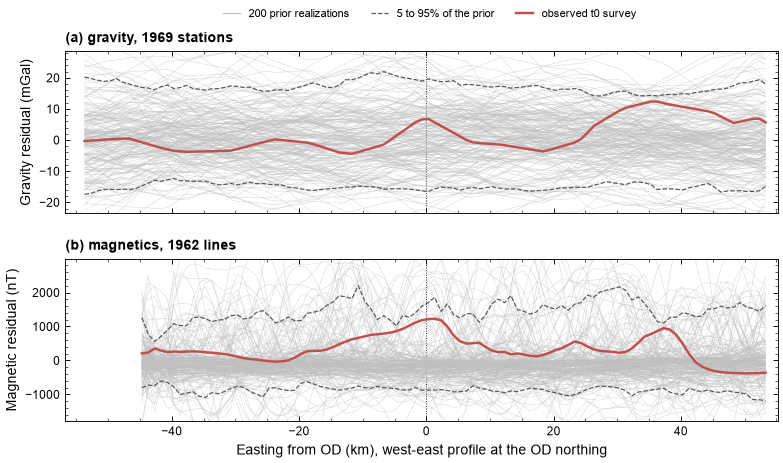

magnetic residual on the grid, bulk statistics (record only, not in the gate): observed | prior 5%, median, 95% of 60 realizations
  sd (nT)                        466.40 |   377.61   680.55   945.49
  interquartile range (nT)       561.41 |   234.29   407.30   804.05
  share of area above 300 nT       0.48 |     0.23     0.41     0.67
  99th percentile over sd          2.69 |     3.03     3.75     4.34
gravity: observed profile inside the 5-95% band at 100% of points; observed range -4.4 to 12.4, prior 5-95% envelope -15.3 to 17.2
magnetics: observed profile inside the 5-95% band at 100% of points; observed range -381.2 to 1224.6, prior 5-95% envelope -888.8 to 1487.1


In [21]:
fig, axes = plt.subplots(2, 1, figsize=(COL2, 4.2), sharex=True)
fig.subplots_adjust(left=0.09, right=0.99, top=0.9, bottom=0.1, hspace=0.28)
for ax, prof, obs, lab in [(axes[0], PROF_G, GRID_G[iy], "Gravity residual (mGal)"), (axes[1], PROF_M, GRID_M[iy], "Magnetic residual (nT)")]:
    for k in range(len(prof)):
        ax.plot(xkm, prof[k], color="0.75", lw=0.35, alpha=0.6, zorder=1)
    lo, hi = np.nanpercentile(prof, 5, axis=0), np.nanpercentile(prof, 95, axis=0)
    ax.plot(xkm, lo, color="0.35", lw=0.8, ls="--", zorder=2); ax.plot(xkm, hi, color="0.35", lw=0.8, ls="--", zorder=2)
    ax.plot(xkm, obs, color="#c0504d", lw=1.6, zorder=3)
    ax.axvline(0, color="k", lw=0.6, ls=":", zorder=0); ax.set_ylabel(lab); ax.set_xlim(xkm[0], xkm[-1])
    ok = np.isfinite(obs); ax.set_ylim(np.nanpercentile(np.r_[prof[:, ok].ravel(), obs[ok]], 0.5), np.nanpercentile(np.r_[prof[:, ok].ravel(), obs[ok]], 99.5))
axes[1].set_xlabel("Easting from OD (km), west-east profile at the OD northing")
panel_labels(axes, ("(a) gravity, 1969 stations", "(b) magnetics, 1962 lines"))
fig.legend(handles=[plt.Line2D([], [], color="0.75", lw=0.8, label=f"{N_ENS} prior realizations"),
                    plt.Line2D([], [], color="0.35", lw=0.8, ls="--", label="5 to 95% of the prior"),
                    plt.Line2D([], [], color="#c0504d", lw=1.6, label="observed t0 survey")],
           loc="upper center", ncol=3, fontsize=FS_ANNOT, bbox_to_anchor=(0.55, 1.01), frameon=False)
fig.savefig(FIG / "wp4_PP_11_profiles_observed_vs_prior.png", dpi=300)
plt.show()
def bulk(grid):
    v = grid[np.isfinite(grid)]
    return dict(sd=v.std(), iqr=np.subtract(*np.percentile(v, [75, 25])), frac_abs_gt300=(abs(v) > 300).mean(), p99_over_sd=np.percentile(abs(v), 99) / v.std())
BULK_M = pd.DataFrame([bulk(anomaly_stats(TRI_M, MXo, MYo, synthetic(s)[5], RULE["T_mag_nt"])[1]) for s in range(SEED0, SEED0 + 60)])
OBS_BULK = bulk(GRID_M)
print("magnetic residual on the grid, bulk statistics (record only, not in the gate): observed | prior 5%, median, 95% of 60 realizations")
for k, lab in [("sd", "sd (nT)"), ("iqr", "interquartile range (nT)"), ("frac_abs_gt300", "share of area above 300 nT"), ("p99_over_sd", "99th percentile over sd")]:
    print(f"  {lab:28s} {OBS_BULK[k]:8.2f} | {np.percentile(BULK_M[k], 5):8.2f} {BULK_M[k].median():8.2f} {np.percentile(BULK_M[k], 95):8.2f}")
for name, prof, obs in [("gravity", PROF_G, GRID_G[iy]), ("magnetics", PROF_M, GRID_M[iy])]:
    ok = np.isfinite(obs) & np.isfinite(prof).all(axis=0)
    inside = ((obs[ok] >= np.percentile(prof[:, ok], 5, axis=0)) & (obs[ok] <= np.percentile(prof[:, ok], 95, axis=0))).mean()
    print(f"{name}: observed profile inside the 5-95% band at {inside*100:.0f}% of points; observed range {np.nanmin(obs):.1f} to {np.nanmax(obs):.1f}, "
          f"prior 5-95% envelope {np.nanpercentile(prof[:, ok], 5):.1f} to {np.nanpercentile(prof[:, ok], 95):.1f}")


### How to read this figure

Grey lines are the 200 realizations, dashed the 5 to 95% envelope, red the survey, dotted the Olympic Dam easting. (a) Gravity: the survey stays inside the envelope; the prior's swings are longer than the observed ones (the 30 km domains). (b) Magnetics: the 4 km texture gives the realizations the survey's short-wavelength roughness and the survey stays inside the band; it sits high because this line crosses the survey's regional high, which the prior places at random. Bulk statistics printed for the record (not in the gate): share of the area above 300 nT 0.41 against 0.48 observed, interquartile range 407 nT against 561, spikiness (99th percentile over sd) 3.8 against 2.7.


## Section 6. Documentary basis

The annex names four tiers of sources (regional frame, the concept, the object analog, the ore analogs) and forbids retrospective accounts as parameter sources. `wp4_annexA_documentary_basis.csv` lists each named item with its status, dates and folder; the Level 5 textbooks and the Middleback reports form two more groups. Status is judged on the information, not the document: an item is found when what the rows need from it is in state before t0, whether in the named document or in a pre-t0 stand-in; the register records which named documents are themselves not on disk and what stands in for them.


### Step 15. The register, audited

Checks: every path exists; nothing dated after t0 except labelled finding aids and cross-checks; no row names a retrospective account; which items rest on a stand-in for a named document that is not in open file.


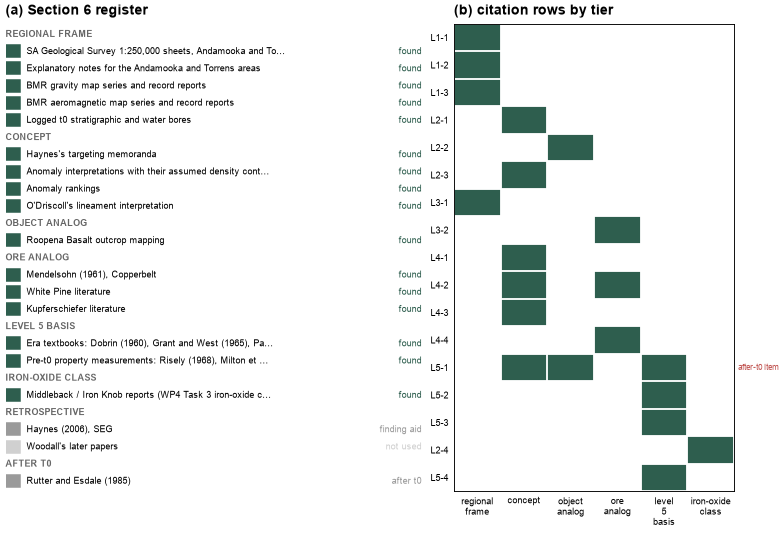

register: 19 items; found 16, finding aid 1, not used 1, after t0 1
paths present: 18 of 18; items dated after t0 outside finding aids: 0
citation rows naming a retrospective account: none
citation rows naming an after-t0 item: {'L5-1': [1985]}
items in state through a stand-in (the named document itself is not on disk): ['BMR gravity map series and record reports', 'BMR aeromagnetic map series and record reports', "Haynes's targeting memoranda", 'Anomaly interpretations with their assumed density contrasts', 'Anomaly rankings', 'Mendelsohn (1961), Copperbelt']
rows resting on a stand-in: ['L2-1', 'L3-2', 'L4-1', 'L4-2', 'L4-4', 'L5-1']


In [22]:
DB = pd.read_csv(PM / "01_citation_table/wp4_annexA_documentary_basis.csv").fillna("")
T0_YEAR = 1975
DB["path_ok"] = [bool(pth) and (PM / pth).exists() for pth in DB.path]
DB["latest_year"] = [max([int(y) for y in str(v).split(";") if y.strip()], default=np.nan) for v in DB.years]
DB["date_ok"] = (DB.latest_year <= T0_YEAR) | DB.status.isin(["finding aid", "after t0", "not used"]) | DB.latest_year.isna()
# the citation table itself: after-t0 years and retrospective accounts named in the in-state sources
after_t0 = {rid: sorted({int(y) for y in re.findall(r"\b(19[0-9]{2}|20[0-2][0-9])\b", CT.loc[rid, "in_state_source_and_date"]) if int(y) > T0_YEAR})
            for rid in CT.index}
after_t0 = {k: v for k, v in after_t0.items() if v}
RETRO = ["Haynes 2006", "Haynes (2006)", "Woodall"]
retro_hits = {rid: [n for n in RETRO if n in CT.loc[rid, "in_state_source_and_date"]] for rid in CT.index}
retro_hits = {k: v for k, v in retro_hits.items() if v}
# row by tier coverage from the register
TIERS = ["regional frame", "concept", "object analog", "ore analog", "level 5 basis", "iron-oxide class"]
RANK = {"found": 3, "partial": 2, "not found": 1}
COV = pd.DataFrame(0, index=CT.index, columns=TIERS)
for _, d in DB[DB.tier.isin(TIERS)].iterrows():
    for rid in [x for x in d.rows.split(";") if x in CT.index]:
        COV.loc[rid, d.tier] = max(COV.loc[rid, d.tier], RANK.get(d.status, 0))
SCOL = {"found": "#2e5e4e", "partial": "#eda100", "not found": "#c0504d", "finding aid": "#9a9a9a", "after t0": "#9a9a9a", "not used": "#d0d0d0"}
fig, axes = plt.subplots(1, 2, figsize=(COL2, 5.0), gridspec_kw={"width_ratios": [1.5, 1]})
fig.subplots_adjust(left=0.01, right=0.93, top=0.93, bottom=0.08, wspace=0.08)
ax = axes[0]; ax.set_xlim(0, 1); ax.axis("off")
prev, i = None, -1
for _, d in DB.iterrows():
    if d.tier != prev:
        i += 1; ax.text(0.0, i + 0.42, d.tier.upper(), fontsize=FS_ANNOT - 1, color="0.4", fontweight="bold", va="center"); prev = d.tier
    i += 1
    ax.add_patch(plt.Rectangle((0.0, i + 0.05), 0.035, 0.7, color=SCOL[d.status]))
    txt = d.annex_item if len(d.annex_item) < 58 else d.annex_item[:55] + "..."
    ax.text(0.05, i + 0.42, txt, fontsize=FS_ANNOT - 1, va="center")
    ax.text(0.99, i + 0.42, d.status + ("" if d.date_ok else "  date!") + ("" if d.path_ok or not d.path else "  path!"),
            fontsize=FS_ANNOT - 1, va="center", ha="right", color=SCOL[d.status])
ax.set_ylim(i + 1, -0.2)
ax = axes[1]
cmap = plt.matplotlib.colors.ListedColormap(["white", SCOL["not found"], SCOL["partial"], SCOL["found"]])
ax.imshow(COV.values, cmap=cmap, vmin=-0.5, vmax=3.5, aspect="auto")
ax.set_xticks(range(len(TIERS))); ax.set_xticklabels([t.replace(" ", "\n") for t in TIERS], fontsize=FS_ANNOT - 1)
ax.set_yticks(range(len(COV))); ax.set_yticklabels(COV.index, fontsize=FS_ANNOT - 1)
ax.set_xticks(np.arange(-0.5, len(TIERS)), minor=True); ax.set_yticks(np.arange(-0.5, len(COV)), minor=True)
ax.grid(which="minor", color="white", lw=1.2); ax.tick_params(which="both", length=0)
for rid in after_t0: ax.text(len(TIERS) - 0.5, list(COV.index).index(rid), "  after-t0 item", fontsize=FS_ANNOT - 2, va="center", color="#c0504d")
panel_labels(axes, ("(a) Section 6 register", "(b) citation rows by tier"))
fig.savefig(FIG / "wp4_PP_12_documentary_basis.png", dpi=300)
plt.show()
print(f"register: {len(DB)} items; " + ", ".join(f"{k} {v}" for k, v in DB.status.value_counts().items()))
print(f"paths present: {int(DB.path_ok.sum())} of {int((DB.path != '').sum())}; items dated after t0 outside finding aids: {int((~DB.date_ok).sum())}")
print("citation rows naming a retrospective account:", retro_hits or "none")
print("citation rows naming an after-t0 item:", after_t0)
sub = DB[(DB.named_item_on_disk == "no") & (DB.status == "found")]
print("items in state through a stand-in (the named document itself is not on disk):", list(sub.annex_item))
print("rows resting on a stand-in:", sorted({r for x in sub.rows for r in x.split(";") if r in CT.index}))


### How to read this figure

(a) The register by tier: green found, grey finding aid, not used or after t0. (b) Which tiers each row rests on. All 18 paths exist and nothing after t0 is used outside the labelled items; no row names Haynes 2006 or Woodall; L5-1 lists Rutter and Esdale 1985 as a cross-check only. Six named documents are not on disk and are covered by stand-ins: the BMR record reports (the station and line data carry what the check uses), Haynes's targeting memoranda (O'Driscoll's 1974 target plans, Johns 1972, Maiden, the EL 190 first quarterly), WMC's model sheets (Risely 1968 and the textbooks), the anomaly rankings (the OD6 iv plan) and Mendelsohn 1961 (Binda and Mulgrew 1974, Annels 1974, Gillson 1963). Rows L2-1, L4-1, L4-2, L5-1, L3-2 and L4-4 rest on those stand-ins; L2-1 remains a declared assumption.


## Section 7. Outputs and interfaces

The deliverable ensemble, the class-agnostic interface, local refinement and the versioned record. **These cells are not executed in the saved notebook; run them locally.** `N_DELIV = 1000` takes about 8 minutes; Section 7 allows up to 10,000.


### Step 16. The branch as data

`BRANCH_SH` is a branch definition: a draw function, the geometry stages, a property stage and a summary. `realize_branch(branch, seed)` runs any branch, so the Ni-Cu, iron-body, VMS and IOCG branches plug in with their own definitions. The check reruns the 50 realizations of Step 6 through the interface against the frozen table `wp4_prior_draws_n50_reference_v2.csv`.


In [23]:
import hashlib
REF = pd.read_csv(TAB / "wp4_prior_draws_n50_reference_v2.csv")
NEW = pd.DataFrame([realize_branch(BRANCH_SH, s)[0] for s in range(1000, 1050)])[REF.columns]
vol_hash = lambda s: hashlib.sha256(np.ascontiguousarray(realize(s, keep_volume=True)[1]["rho"]).tobytes()).hexdigest()[:16]
print("branch:", BRANCH_SH["name"]); print("  geometry family:", BRANCH_SH["geometry_family"])
print("  mineralization rule:", BRANCH_SH["mineralization_rule"])
print("  stages:", [f.__name__ for f in BRANCH_SH["stages"]], "+", BRANCH_SH["properties"].__name__)
print(f"interface check: 50 realizations through realize_branch() against the reference table, max abs difference {np.nanmax(abs(NEW.values - REF.values)):.1e}")
print(f"seed convention: default_rng(seed); seed 43 volume hash {vol_hash(43)} and again {vol_hash(43)}")


branch: sediment-hosted Cu, Annex A
  geometry family: flat-lying cover stack; flow-pile ellipses on the basement surface
  mineralization rule: ore disks in the margin zone: within d of a basalt edge and on a reduced belt
  stages: ['level1_frame', 'level2_basalt', 'level3_redox', 'level4_ore', 'level2_iron', 'level5_basement'] + level5_properties
interface check: 50 realizations through realize_branch() against the reference table, max abs difference 1.8e-12
seed convention: default_rng(seed); seed 43 volume hash 039d1841da97ef70 and again 039d1841da97ef70


### Reading the output

The difference should be of order 1e-13 and the two volume hashes identical: the seed alone reproduces a realization, volumes included.


### Step 17. The deliverable ensemble and its likelihood weights

Each of `N_DELIV` realizations is forward-modelled and weighted against the t0 surveys with a Gaussian likelihood and a free regional plane $\mathbf{P}\boldsymbol\beta$ fitted per realization:

$$\log L = -\tfrac{1}{2}\sum_i \left(\frac{d_i - s_i - (\mathbf{P}\boldsymbol\beta)_i}{\sigma_i}\right)^2,\qquad w \propto \exp(\log L_g + \log L_m),\qquad \mathrm{ESS} = 1/\textstyle\sum w^2 .$$

Volumes are not stored; a seed regenerates them. Written: `wp4_prior_ensemble_n1000.csv` and the top-weighted volumes in `ensemble/`.


In [24]:
import time
N_DELIV = 1000          # Section 7 asks for 1,000 to 10,000; about 0.3 s per realization (1,000 in about 5 min)
def loglik(x, y, obs, syn, sd):
    """Gaussian log-likelihood of the data given a realization, with an unknown regional plane removed from the misfit"""
    A = np.c_[np.ones_like(x), (x - X0) / 1e3, (y - Y0) / 1e3]; d = obs - syn
    res = d - A @ np.linalg.lstsq(A, d, rcond=None)[0]
    return -0.5 * np.sum((res / sd) ** 2), res
t0 = time.time(); rows = []
for s in range(SEED0, SEED0 + N_DELIV):
    o, mp, g, t, gs, ms = synthetic(s, rng_noise=False)
    lg, _ = loglik(GXo, GYo, G_OBS, gs, G_SD); lm, _ = loglik(MXo, MYo, M_OBS, ms, RULE["mag_noise_nt"])
    rows.append({**o, "loglik_grav": lg, "loglik_mag": lm})
ENS = pd.DataFrame(rows)
def weights(ll):
    w = np.exp(ll - ll.max()); return w / w.sum()
for tag, ll in [("grav", ENS.loglik_grav), ("mag", ENS.loglik_mag), ("joint", ENS.loglik_grav + ENS.loglik_mag)]:
    ENS["w_" + tag] = weights(ll.values)
ESS = {tag: 1.0 / np.sum(ENS["w_" + tag] ** 2) for tag in ("grav", "mag", "joint")}
ENS.to_csv(TAB / "wp4_prior_ensemble_n1000.csv", index=False)
TOP = int(ENS.loc[ENS.w_joint.idxmax(), "seed"])
o, mp, _, _ = realize(TOP, keep_volume=True)
(TAB / "ensemble").mkdir(exist_ok=True)
np.savez_compressed(TAB / "ensemble" / f"wp4_prior_seed{TOP}_volumes.npz", lith=mp["lith"], rho=mp["rho"], k=mp["k"], res=mp["res"],
                    x=XC, y=YC, z=ZC, seed=TOP)
_, _, _, _, gs_top, ms_top = synthetic(TOP, rng_noise=False)
_, res_top = loglik(GXo, GYo, G_OBS, gs_top, G_SD)
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.5))
fig.subplots_adjust(left=0.08, right=0.99, top=0.84, bottom=0.2, wspace=0.42)
ax = axes[0]; ax.scatter(ENS.loglik_grav - ENS.loglik_grav.max(), ENS.loglik_mag - ENS.loglik_mag.max(), s=4, color="#2e5e4e", alpha=0.6)
ax.set_xscale("symlog"); ax.set_yscale("symlog")
ax.set_xlabel("Gravity log-lik. less best"); ax.set_ylabel("Magnetic log-lik. less best")
ax = axes[1]; ws = np.sort(ENS.w_joint.values)[::-1]
ax.plot(np.arange(1, 21), np.cumsum(ws[:20]), "o-", color="#c0504d", ms=3, lw=1)
ax.set_xlabel("Top-k realizations"); ax.set_ylabel("Cumulative weight"); ax.set_ylim(0, 1.05)
ax = axes[2]; ax.scatter(detrend(GXo, GYo, G_OBS), detrend(GXo, GYo, gs_top), s=5, color="#2a78d6")
lim = [-15, 15]; ax.plot(lim, lim, color="0.5", lw=0.6, ls=":"); ax.set_xlim(lim); ax.set_ylim(-5, 5)
ax.set_xlabel("Observed residual (mGal)"); ax.set_ylabel(f"Seed {TOP} residual (mGal)")
panel_labels(axes, ("(a)", "(b)", "(c)"))
fig.savefig(FIG / "wp4_PP_13_ensemble_weights.png", dpi=300)
plt.show()
per_real = sum(mp[k].nbytes for k in ("lith", "rho", "k", "res"))
print(f"{N_DELIV} realizations (seeds {SEED0}-{SEED0 + N_DELIV - 1}) forward-modelled and weighted in {time.time() - t0:.0f} s")
print(f"effective sample size: gravity {ESS['grav']:.2f}, magnetics {ESS['mag']:.2f}, joint {ESS['joint']:.2f} of {N_DELIV}")
print(f"top-weighted realization: seed {TOP}, joint weight {ENS.w_joint.max():.3f}; its volumes saved to ensemble/wp4_prior_seed{TOP}_volumes.npz")
print(f"gravity misfit sd for seed {TOP}: {res_top.std():.2f} mGal against a noise sd of {np.median(G_SD):.2f}")
print(f"full volumes would take {per_real / 1e6:.1f} MB per realization, {per_real * 1e4 / 1e9:.0f} GB for 10,000; stored instead: seeds, draws, summaries, log-likelihoods")


KeyboardInterrupt: 

### How to read this figure

(a) Gravity against magnetic log-likelihood, relative to the best. (b) Cumulative weight of the top 20. (c) Observed gravity residual against the top-weighted realization at the 342 stations. With survey noise alone on 25,000 readings the weights collapse onto one realization (a 20-member smoke test gave ESS 1.0): the point-wise likelihood is far sharper than the prior, which is the weighting step saying what the gate said. Model error, tempering or a likelihood on summary statistics belongs to WP3.


### Step 18. Local refinement around a ranked anomaly

The observed gravity anomalies of Step 8 are ranked by peak. `refine(seed, x, y)` regenerates the same realization on a 250 m grid in a 20 km box: surfaces interpolated, basalt ellipses and ore disks redrawn from their stored centres and sizes.


In [ ]:
# rank the observed gravity anomalies of Step 8 by peak; refine one realization around the first
labG, nG = ndimage.label(ANOM_G, structure=np.ones((3, 3)))
RANKED = pd.DataFrame([dict(anomaly=i, peak_mgal=np.nanmax(np.where(labG == i, GRID_G, np.nan)),
                            x=GX[labG == i][np.nanargmax(GRID_G[labG == i])], y=GY[labG == i][np.nanargmax(GRID_G[labG == i])],
                            area_km2=int((labG == i).sum())) for i in range(1, nG + 1)]).sort_values("peak_mgal", ascending=False)
RANKED["rank"] = np.arange(1, len(RANKED) + 1)

def refine(seed, x0, y0, half_km=10.0, dxf=250.0):
    """the same realization on a local grid of dxf cells: surfaces interpolated, objects and ore disks re-drawn exactly"""
    out, maps, objs, ores = realize(seed)
    xf = np.arange(x0 - half_km * 1e3 + dxf / 2, x0 + half_km * 1e3, dxf); yf = np.arange(y0 - half_km * 1e3 + dxf / 2, y0 + half_km * 1e3, dxf)
    GXf, GYf = np.meshgrid(xf, yf); pts = np.c_[GYf.ravel(), GXf.ravel()]
    S = {k: RegularGridInterpolator((YC, XC), maps[k], bounds_error=False, fill_value=None)(pts).reshape(GXf.shape)
         for k in ("s1", "s2", "s3", "cover", "base")}
    near = lambda a: a[np.clip(np.searchsorted(YC, GYf) - 1, 0, NY - 1), np.clip(np.searchsorted(XC, GXf) - 1, 0, NX - 1)]
    btop = np.full(GXf.shape, np.nan); a = np.radians(FIX["basalt_az"])
    for _, ob in objs.iterrows():
        u = (GXf - ob.x) / 1e3 * np.sin(a) + (GYf - ob.y) / 1e3 * np.cos(a); v = (GXf - ob.x) / 1e3 * np.cos(a) - (GYf - ob.y) / 1e3 * np.sin(a)
        m = (u / (ob.length_km / 2)) ** 2 + (v / (ob.length_km / 2 / FIX["basalt_aspect"])) ** 2 <= 1
        btop = np.where(m, np.maximum(S["base"] - ob.thickness_m, S["cover"]), btop)
    ore = np.zeros(GXf.shape, bool)
    for _, e in ores.iterrows(): ore |= (GXf - e.x) ** 2 + (GYf - e.y) ** 2 <= (e.diam_km * 1e3 / 2) ** 2
    z = ZC[None, None, :]; lith = np.full(GXf.shape + (len(ZC),), 7, np.int8)
    for code, surf in [(1, S["s1"]), (2, S["s2"]), (3, S["s3"]), (4, S["cover"]), (5, S["base"])]:
        lith[(lith == 7) & (z < surf[:, :, None])] = code
    lith[(z >= btop[:, :, None]) & (z < S["base"][:, :, None]) & np.isfinite(btop)[:, :, None]] = 6
    return dict(x=xf, y=yf, lith=lith, ore=ore, reduced=near(maps["reduced"]), contact=np.where(np.isfinite(btop), btop, S["base"]))

A1 = RANKED.iloc[0]
FINE = refine(TOP, A1.x, A1.y)
_, mcoarse, _, _ = realize(TOP, keep_volume=True)
jy_c = int(np.argmin(abs(YC - A1.y))); jy_f = int(np.argmin(abs(FINE["y"] - A1.y)))
ixc = (XC >= A1.x - 10e3) & (XC <= A1.x + 10e3)
lcmap = plt.matplotlib.colors.ListedColormap([UNIT_COL[c] for c in range(1, 8)])
zb = np.r_[0, np.cumsum(HZ)]
fig, axes = plt.subplots(2, 1, figsize=(COL15, 3.6), sharex=True)
fig.subplots_adjust(left=0.12, right=0.97, top=0.9, bottom=0.13, hspace=0.3)
xe_c = (np.r_[XC[ixc] - DX / 2, XC[ixc][-1] + DX / 2] - A1.x) / 1e3
axes[0].pcolormesh(xe_c, zb, mcoarse["lith"][jy_c][ixc].T, cmap=lcmap, vmin=0.5, vmax=7.5, shading="flat", rasterized=True)
xe_f = (np.r_[FINE["x"] - 125, FINE["x"][-1] + 125] - A1.x) / 1e3
axes[1].pcolormesh(xe_f, zb, FINE["lith"][jy_f].T, cmap=lcmap, vmin=0.5, vmax=7.5, shading="flat", rasterized=True)
xo = (FINE["x"][FINE["ore"][jy_f]] - A1.x) / 1e3
if len(xo): axes[1].plot(xo, FINE["contact"][jy_f][FINE["ore"][jy_f]], "|", color="#b0302a", ms=6)
for ax in axes: ax.set_ylim(1500, 0); ax.set_xlim(-10, 10); ax.set_ylabel("Depth (m)")
axes[1].set_xlabel(f"Easting from ranked anomaly 1 (km)")
panel_labels(axes, (f"(a) seed {TOP}, regional grid (1 km)", f"(b) same realization refined on demand (250 m)"))
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=UNIT_COL[c], label=LITH[c]) for c in range(1, 8)], loc="upper center", ncol=7,
           fontsize=FS_ANNOT - 2, bbox_to_anchor=(0.54, 1.01), frameon=False, handlelength=0.9, columnspacing=0.6)
fig.savefig(FIG / "wp4_PP_14_local_refinement.png", dpi=300)
plt.show()
print(RANKED.head(5).assign(x=lambda d: ((d.x - ODX) / 1e3).round(1), y=lambda d: ((d.y - ODY) / 1e3).round(1)).rename(
      columns={"x": "east_of_OD_km", "y": "north_of_OD_km"}).round(2).to_string(index=False))
print(f"refined grid {len(FINE['x'])} x {len(FINE['y'])} x {len(ZC)} cells of 250 m; basalt cells {int((FINE['lith'] == 6).sum())}, "
      f"ore footprint {FINE['ore'].sum() * 0.0625:.1f} km2 in the box")


### How to read this figure

(a) The top-weighted realization on the 1 km grid, west to east through ranked anomaly 1 (Step 17 must have run). (b) The same realization at 250 m. Unit boundaries must agree; object edges are sharper in (b). The printed table lists the five highest-ranked observed anomalies.


### Step 19. The versioned record


In [ ]:
import json, datetime
sha = lambda path: hashlib.sha256(Path(path).read_bytes()).hexdigest()[:12]
VERSION = {"prior": "WP4 Annex A, sediment-hosted branch", "version": "0.7", "status": "Change 6 (2026-09-23): L1-1 as one draw, total cover to basement Uniform(320, 670) m from the cited bores (Bulletin 41, Johns 1974, LY 2), unit thicknesses as fixed shares; the Change 1 and 2 rows bundled by the annex convention (L2-4 iron-oxide body size; density, L5-4 basement density; susceptibility variation), 17 rows; reference draws v2. Change 1 (2026-09-23): basement density field L5-4, iron-oxide bodies L2-4 and L5-5; L5-1 unit erratum corrected; Change 2: independent basement susceptibility field L5-6; Change 3: susceptibility patch size 16 km (fixed setting, chosen from a sensitivity set with the count statistic in view); Change 4: susceptibility median 1,120 x 1e-6 cgs (Grant and West 1965 Table 12-3, rhyolite mean, the Gawler Range Volcanics analog; chosen between the table values 500 and 2,700 after both were run against the survey); Change 5: two-scale basement fields, 30 km domains plus 4 km texture with 80% of the variance at the domain scale (fixed settings; scales from the era maps, share declared and chosen with the count statistic in view)",
           "t0": "1975-05-02", "built": str(datetime.date.today()),
           "citation_table_sha": sha(PM / "01_citation_table/wp4_annexA_citation_table_draft.csv"),
           "documentary_basis_sha": sha(PM / "01_citation_table/wp4_annexA_documentary_basis.csv"),
           "sampler_sha": sha(PM / "08_prior_models/wp4_sh_prior_sampler.py"),
           "seed_convention": "numpy default_rng(seed); synthetic noise default_rng(seed + 10,000,000)",
           "seeds": {"figures": [43, 77, 99], "row_check": [1000, 1049], "predictive_check": [SEED0, SEED0 + N_ENS - 1],
                     "deliverable_ensemble": [SEED0, SEED0 + N_DELIV - 1]},
           "section4_rule": RULE, "field_1962": FIELD,
           "section4_gate": GATE.groupby(["field", "status"]).size().unstack(fill_value=0).to_dict(orient="index"),
           "effective_sample_size": {k: round(float(v), 3) for k, v in ESS.items()}, "top_weighted_seed": TOP}
TAG = f"WP4-A-SH v{VERSION['version']} ({VERSION['citation_table_sha']})"
(TAB / "wp4_prior_version.json").write_text(json.dumps(VERSION, indent=2, default=float))
print("prior version tag:", TAG); print(json.dumps(VERSION, indent=2, default=float))


### Reading the output

`wp4_prior_version.json` names the prior (WP4-A-SH v0.7), the hashes of the citation table, the register and the sampler module, the seed conventions, the Section 4 rule and gate, and the effective sample size. Every downstream figure should quote the tag.


## What this shows

The recipe runs from the 17-row table under the Section 2 rules: every draw traces to a pre-1975 document, and the surveys enter only at the gate and in the weights. Gravity passes all five statistics and magnetics four; the one warning, the anomaly count, is a scale choice (count against width) made in the fixed two-scale geometry and recorded as such. Changes 1 and 2 came from sources; Changes 3 to 5 are settings chosen with the check in view; Change 6 is the annex's own reading of its table.

Open: the L1-1 upper bound (LY 2 did not reach basement; sensitivity to report); the unit shares and the two-scale settings (declared); fixed settings without rows; tonnage; basalt placement; the level-notebook rulings. Next: the Section 7 ensemble (run locally) and the WP3 weighting.
